In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
from metab_processing.metab_travlr_config import DATA_DIR


PROJECT = 'Alexi_UC_Spliced'
PROJECT_DIR = f'{DATA_DIR}/{PROJECT}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# This is for loading the coefficients into the adata, which requires spacetravlr to be installed (or at least some of its required arrays)

# adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
# adata

# from metab_processing.SpaceTravLR import beta_analysis

# betadata_dir = f'{DATA_DIR}/spacetravlr_output/betadata'
# beta_analysis.betas_to_adata(adata, betadata_dir, group=None)
# print(adata)
# adata.write_h5ad(f"{DATA_DIR}/spacetravlr_adata.h5ad")
# del adata

In [4]:
PATIENT = '13473_HS4_UC'
SLICE = 2
DATASET_NAME = f'{PATIENT}-Slice_{SLICE}'
DATA_DIR = f'{PROJECT_DIR}/{DATASET_NAME}'
adata = sc.read_h5ad(f'{DATA_DIR}/all_metab_spacetravlr_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 9930 × 4736
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'orientation_cores', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'leiden', 'leiden_res_1_5', 'leiden_res_1_3', 'leiden_res_1_4', 'leiden_res_1_6', 'leiden_res_1_2', '25_06_11_ICI_5K_Compartments', '24_11_12_ICI_5K_Fine_annotations', '25_06_11_ICI_5K_Coarse_annotations', '240927_Condition', '25_06_11_Patient_ID_HS', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_co

/tmp/ipykernel_1219656/3727956402.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='25_06_11_ICI_5K_Coarse_annotations');


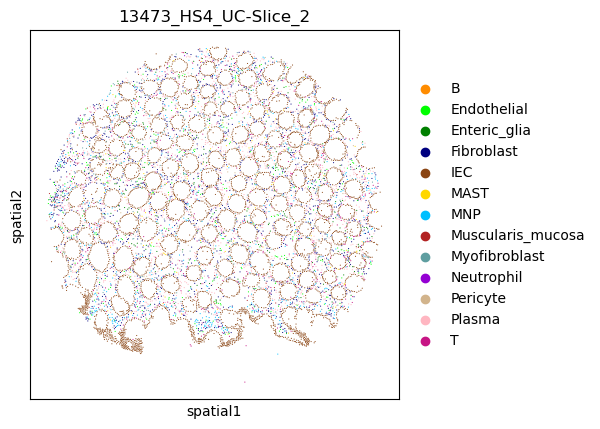

In [5]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='25_06_11_ICI_5K_Coarse_annotations');

In [6]:
list(adata.uns['beta_modulators'])

['CD3E',
 'CD3G',
 'CD4',
 'CTLA4',
 'ENTPD1',
 'FOXP3',
 'HAVCR2',
 'HIF1A',
 'IL10',
 'IL2RA',
 'LAG3',
 'MYC',
 'PDCD1',
 'TBP',
 'TCF7',
 'TOX']

In [7]:
GENE = 'CD3E'
adata.uns['beta_modulators'][GENE]

array(['ARID3B', 'BCL6', 'BCL6B', 'CTCF', 'EHF', 'ELK4', 'EP300', 'ESRRA',
       'ETV5', 'FLI1', 'FOXA1', 'FOXI1', 'FOXJ2', 'FOXL2', 'FOXO1',
       'FOXO3', 'FOXO4', 'GATA1', 'GATA2', 'GATA3', 'HOXA5', 'HOXB4',
       'HOXB6', 'HOXB7', 'HOXB9', 'IRX1', 'MECOM', 'MEF2A', 'MYEF2',
       'NR3C1', 'PDX1', 'PITX1', 'POU1F1', 'POU2F1', 'PPARGC1A', 'RUNX1',
       'SIN3A', 'SMAD4', 'STAT1', 'STAT3', 'STAT5A', 'STAT5B', 'TCF7L2',
       'THRA', 'THRB', 'ZBTB1', 'TGFB1$TGFBR2', 'BMP2$BMPR1A',
       'BMP2$ACVR2A', 'BMP2$BMPR2', 'BMP4$ACVR2A', 'BMP4$BMPR2',
       'BMP6$BMPR2', 'BMP7$BMPR2', 'PDGFA$PDGFRA', 'IHH$PTCH1', 'IHH$SMO',
       'CCL15$CCR1', 'CXCL12$CXCR4', 'CXCL12$ACKR3', 'CXCL16$CXCR6',
       'IL7$IL2RG', 'IL15$IL2RB', 'IL15$IL2RG', 'LIF$IL6ST', 'IL16$CD4',
       'TNFSF14$TNFRSF14', 'TNFSF10$TNFRSF10A', 'CD40LG$ITGB2',
       'POSTN$ITGAV', 'POSTN$ITGB3', 'POSTN$ITGB5', 'GAS6$AXL',
       'GAS6$MERTK', 'GAS6$TYRO3', 'GRN$SORT1', 'GUCA2A$GUCY2C',
       'PROS1$AXL', 'BTLA$TNFRSF1

In [8]:
def plot_beta(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['beta'] = sub.obsm[f'beta_{gene}'][:, i]
    sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
                  title=f'{gene} ~ {modulator} ({tier})')

/tmp/ipykernel_1219656/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_1219656/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_1219656/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_1219656/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,


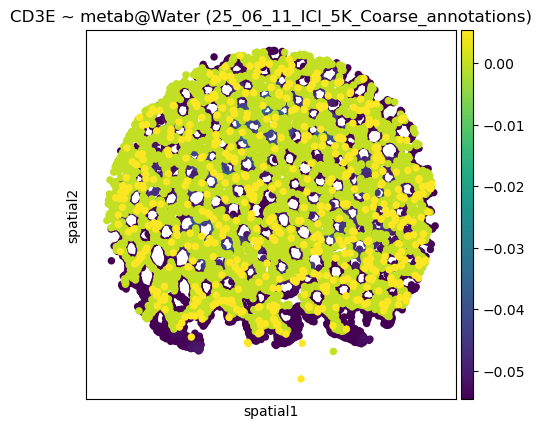

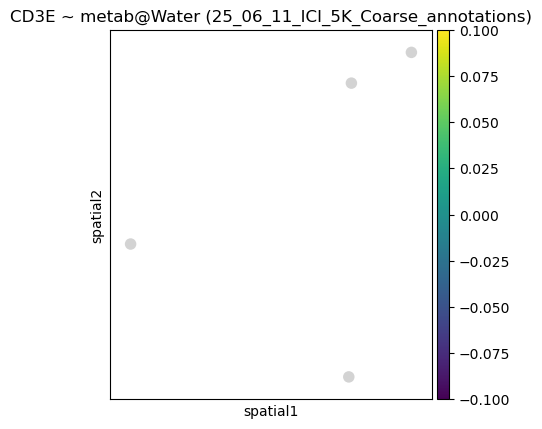

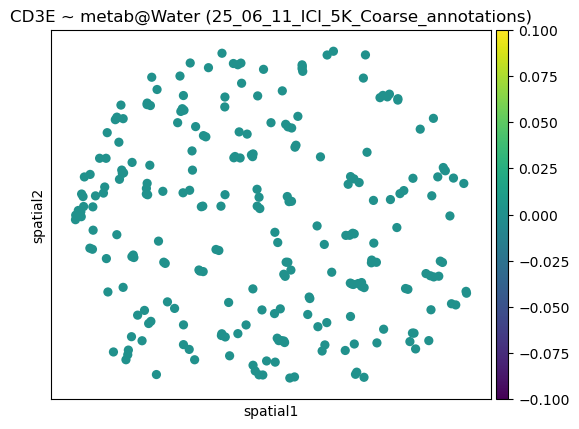

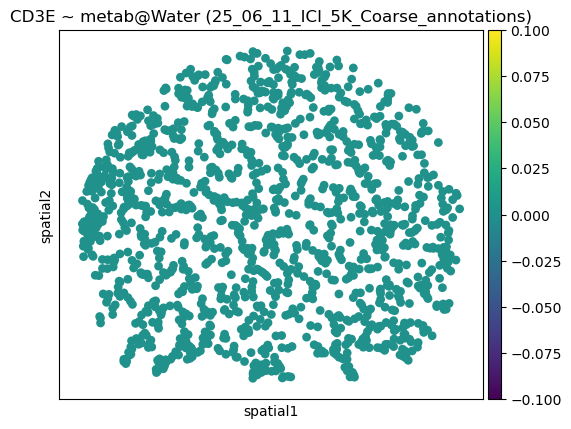

In [9]:
# gp = [m for m in adata.uns['beta_modulators'][GENE] if '@' in m][1]
gp = 'metab@Water'
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations')
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['B'])
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['Endothelial'])
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['Fibroblast'])

In [10]:
adata.uns['beta_modulators']['FOXP3'] # Note that this demonstrates that we have no metabolite gene pairs (indicated with @),
# ie all the gps were zeroed out in training. This also shows that if we have a beta_modulator, then it is non zero on some cell

array(['AR', 'BCL3', 'CTCF', 'CTCFL', 'EBF1', 'EGR2', 'ESR2', 'FOXA1',
       'FOXE1', 'FOXE3', 'FOXI1', 'FOXL2', 'GATA2', 'GATA3', 'GLIS3',
       'HDAC2', 'HIVEP2', 'KLF5', 'MAX', 'NFATC1', 'NFATC2', 'NFATC3',
       'NFATC4', 'NFKB1', 'NR3C1', 'NR3C2', 'NRF1', 'PAX5', 'PAX7', 'PGR',
       'POU5F1', 'RBPJ', 'REL', 'REST', 'RFX1', 'RXRA', 'SMC3', 'SRF',
       'TAL1', 'TBX2', 'TBX21', 'TBX4', 'TBX5', 'TP63', 'ZIC4', 'ZNF281',
       'metab@D-Glucose', 'metab@D-Galactose|D-Mannose',
       'metab@Glucosamine',
       'metab@Docosahexaenoic acid|Dehydroascorbic acid',
       'metab@L-Glutamine', 'metab@Nicotinate', 'metab@L-Glutamate',
       'metab@Iron', 'metab@Acetyl-L-Carnitine', 'metab@L-Carnitine',
       'metab@Sodium', 'metab@L-Leucine', 'metab@Fatty acid',
       'metab@Creatine', 'metab@Choline', 'metab@Cholesterol',
       'metab@Taurocholic acid',
       'metab@Cortisol|N-Desmethyltamoxifen|Hydroxylansoprazole',
       'metab@Glutathione',
       'metab@Glycerol|Estriol|O-D

In [11]:
def get_betas_modulator(adata, gene, modulator, tier=None, cell_types=None):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'beta_{gene}'][:, i]

def agg_modulator(adata, gene, modulator, tier=None, cell_types=None):
    betas = get_betas_modulator(adata, gene, modulator, tier, cell_types)
    return np.mean(betas), np.std(betas)

agg_modulator(adata, GENE, 'NFKB1', '25_06_11_ICI_5K_Coarse_annotations', cell_types=['Fibroblast'])
        

(np.float32(0.1401727), np.float32(0.0026225094))

In [12]:
harr_data_path = f'{DATA_DIR}/easy_download/harreman_outputs/[ccc_results][cell_com_df_m].csv'
harr_data = pd.read_csv(harr_data_path)
harr_data

,Unnamed: 0,Metabolite,C_p,Z,Z_pval,Z_FDR,C_np,pval_np,FDR_np,selected
0,0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",-459.646981,-0.298518,6.173459e-01,7.068163e-01,3948.940904,0.067932,0.090960,False
1,1,17a-Ethynylestradiol,3645.960333,3.305502,4.740323e-04,1.468571e-03,10757.011823,0.000999,0.002466,True
2,2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",-459.646981,-0.298518,6.173459e-01,7.068163e-01,3948.940904,0.067932,0.090960,False
3,3,2-Hydroxychlorpropamide,5595.031527,10.034474,5.376537e-24,1.213561e-22,18492.207878,0.000999,0.002466,True
4,4,25-Hydroxycholesterol,2518.800667,8.357461,3.204123e-17,6.328142e-16,4016.136019,0.000999,0.002466,True
...,...,...,...,...,...,...,...,...,...,...
153,153,Vitamin D3,2392.531221,7.938495,1.023246e-15,1.616728e-14,508.312040,0.000999,0.002466,True
154,154,Water,6034.276037,2.317184,1.024685e-02,2.698337e-02,92944.240997,0.000999,0.002466,True
155,155,Zinc,2164.369290,2.855517,2.148340e-03,6.171595e-03,3848.658861,0.000999,0.002466,True
156,156,alpha-Ketoisovaleric acid,-15.511737,-0.051468,5.205239e-01,7.068163e-01,867.283434,0.000999,0.002466,True


In [13]:
def _modulator_members(modulator):
    """'metab@A|B|C' -> ['A', 'B', 'C'] (exact whole-metabolite names)."""
    name = modulator.split('@', 1)[1] if '@' in modulator else modulator
    return name.split('|')


def mean_abs_coeff(adata, TARGET_GENE, modulator):
    betas = np.nan_to_num(get_betas_modulator(adata, TARGET_GENE, modulator))
    return np.mean(np.abs(betas)), np.std(betas)


def extract_betas(TARGET_GENE, adata):
    """One row per metabolite: avg |β|, β std, and both FDRs. Returns a DataFrame."""
    modulators = adata.uns['beta_modulators'][TARGET_GENE]
    rows = []

    for metab in harr_data['Metabolite']:
        # EXACT membership, not substring: 'Adenosine' no longer matches
        # 'Adenosine triphosphate' or 'Adenosine diphosphate ribose'.
        match = [m for m in modulators if metab in _modulator_members(m)]

        if len(match) > 1:
            print(f"WARNING: {metab} matched multiple modulators: {match}")
            continue
        elif len(match) == 0:
            avg_coeff, std_coeff = 0.0, np.nan
        else:
            avg_coeff, std_coeff = mean_abs_coeff(adata, TARGET_GENE, match[0])

        h = harr_data.loc[harr_data['Metabolite'] == metab].iloc[0]
        rows.append({
            'metabolite': metab,
            'avg_coeff': avg_coeff,
            'std_coeff': std_coeff,
            'FDR_np': float(h['FDR_np']),
            'Z_FDR': float(h['Z_FDR']),
        })

    return pd.DataFrame(rows)


def plot_betas(df, fdr_col='Z_FDR', TARGET_GENE='', ax=None,
               labels=True, xlim=None, ylim=None):
    """Scatter avg |β| vs -log10(FDR). Set labels=False to hide text;
    pass xlim/ylim tuples to zoom."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x = df['avg_coeff'].to_numpy()
    y = -np.log10(df[fdr_col].to_numpy())

    ax.scatter(x, y, s=30, alpha=0.8)
    ax.axhline(-np.log10(0.05), ls='--', lw=1, color='grey', label='FDR = 0.05')
    ax.axvline(0, ls=':', lw=1, color='grey')
    ax.set_xlabel('Average |modulator coefficient| (|β|)')
    ax.set_ylabel(f'-log10({fdr_col})')
    ax.set_title(f'{TARGET_GENE}: {fdr_col} vs avg |β|')
    ax.legend()

    if labels:
        for m, xi, yi in zip(df['metabolite'], x, y):
            if xi != 0:
                ax.annotate(m, (xi, yi), fontsize=7,
                            xytext=(3, 3), textcoords='offset points')

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    return ax

fdr_vs_bata_df = extract_betas('CD3E', adata)

In [14]:
mean_abs_coeff(adata, 'CD3E', 'metab@Water')
np.sum(np.isnan(get_betas_modulator(adata, 'CD3E', 'metab@Water')))

np.int64(5)

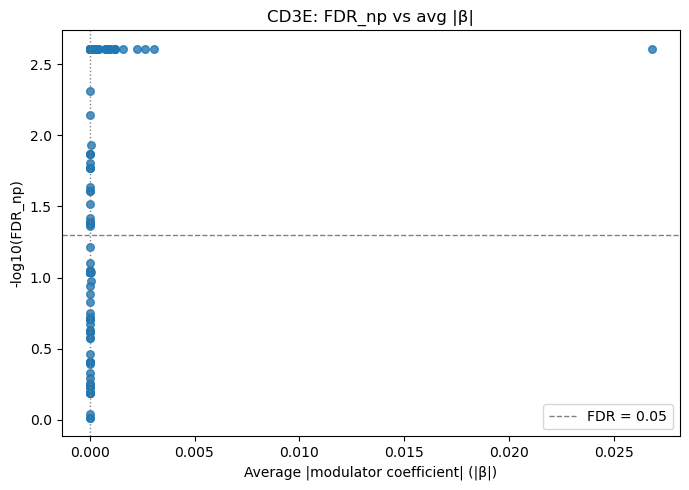

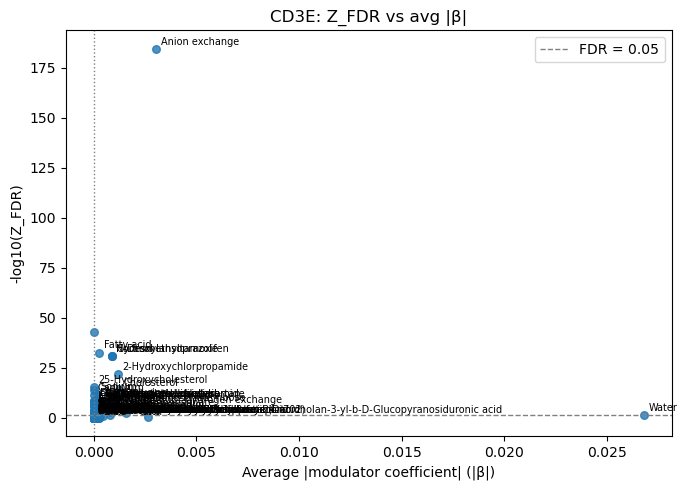

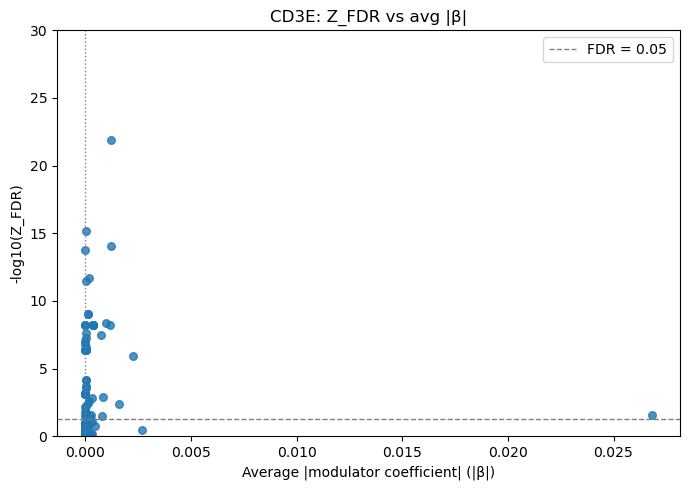

In [15]:
plot_betas(fdr_vs_bata_df, fdr_col='FDR_np', labels=False, TARGET_GENE='CD3E')
plt.tight_layout()
plt.show()

plot_betas(fdr_vs_bata_df, fdr_col='Z_FDR', TARGET_GENE='CD3E')
plt.tight_layout()
plt.show()

# zoom in on the crowded region near the x-axis, no labels
plot_betas(fdr_vs_bata_df, fdr_col='Z_FDR', TARGET_GENE='CD3E', labels=False, ylim=(0, 30))
plt.tight_layout()
plt.show()

In [16]:
def extract_betas_all(target_genes, adata):
    """{gene: DataFrame} — one extract_betas result per target gene."""
    return {gene: extract_betas(gene, adata) for gene in target_genes}


def plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False, ncols=3,
                    xlim=None, ylim=None, figsize=None):
    """Plot every gene's df in a grid. `dfs` is the {gene: DataFrame} dict."""
    genes = list(dfs)
    ncols = min(ncols, len(genes))
    nrows = -(-len(genes) // ncols)  # ceil
    if figsize is None:
        figsize = (5 * ncols, 4 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for ax, gene in zip(axes, genes):
        plot_betas(dfs[gene], fdr_col=fdr_col, TARGET_GENE=gene, ax=ax,
                   labels=labels, xlim=xlim, ylim=ylim)

    for ax in axes[len(genes):]:  # hide unused panels
        ax.axis('off')

    fig.tight_layout()
    return fig, axes

genes = list(adata.uns['beta_modulators'])
dfs = extract_betas_all(genes, adata)

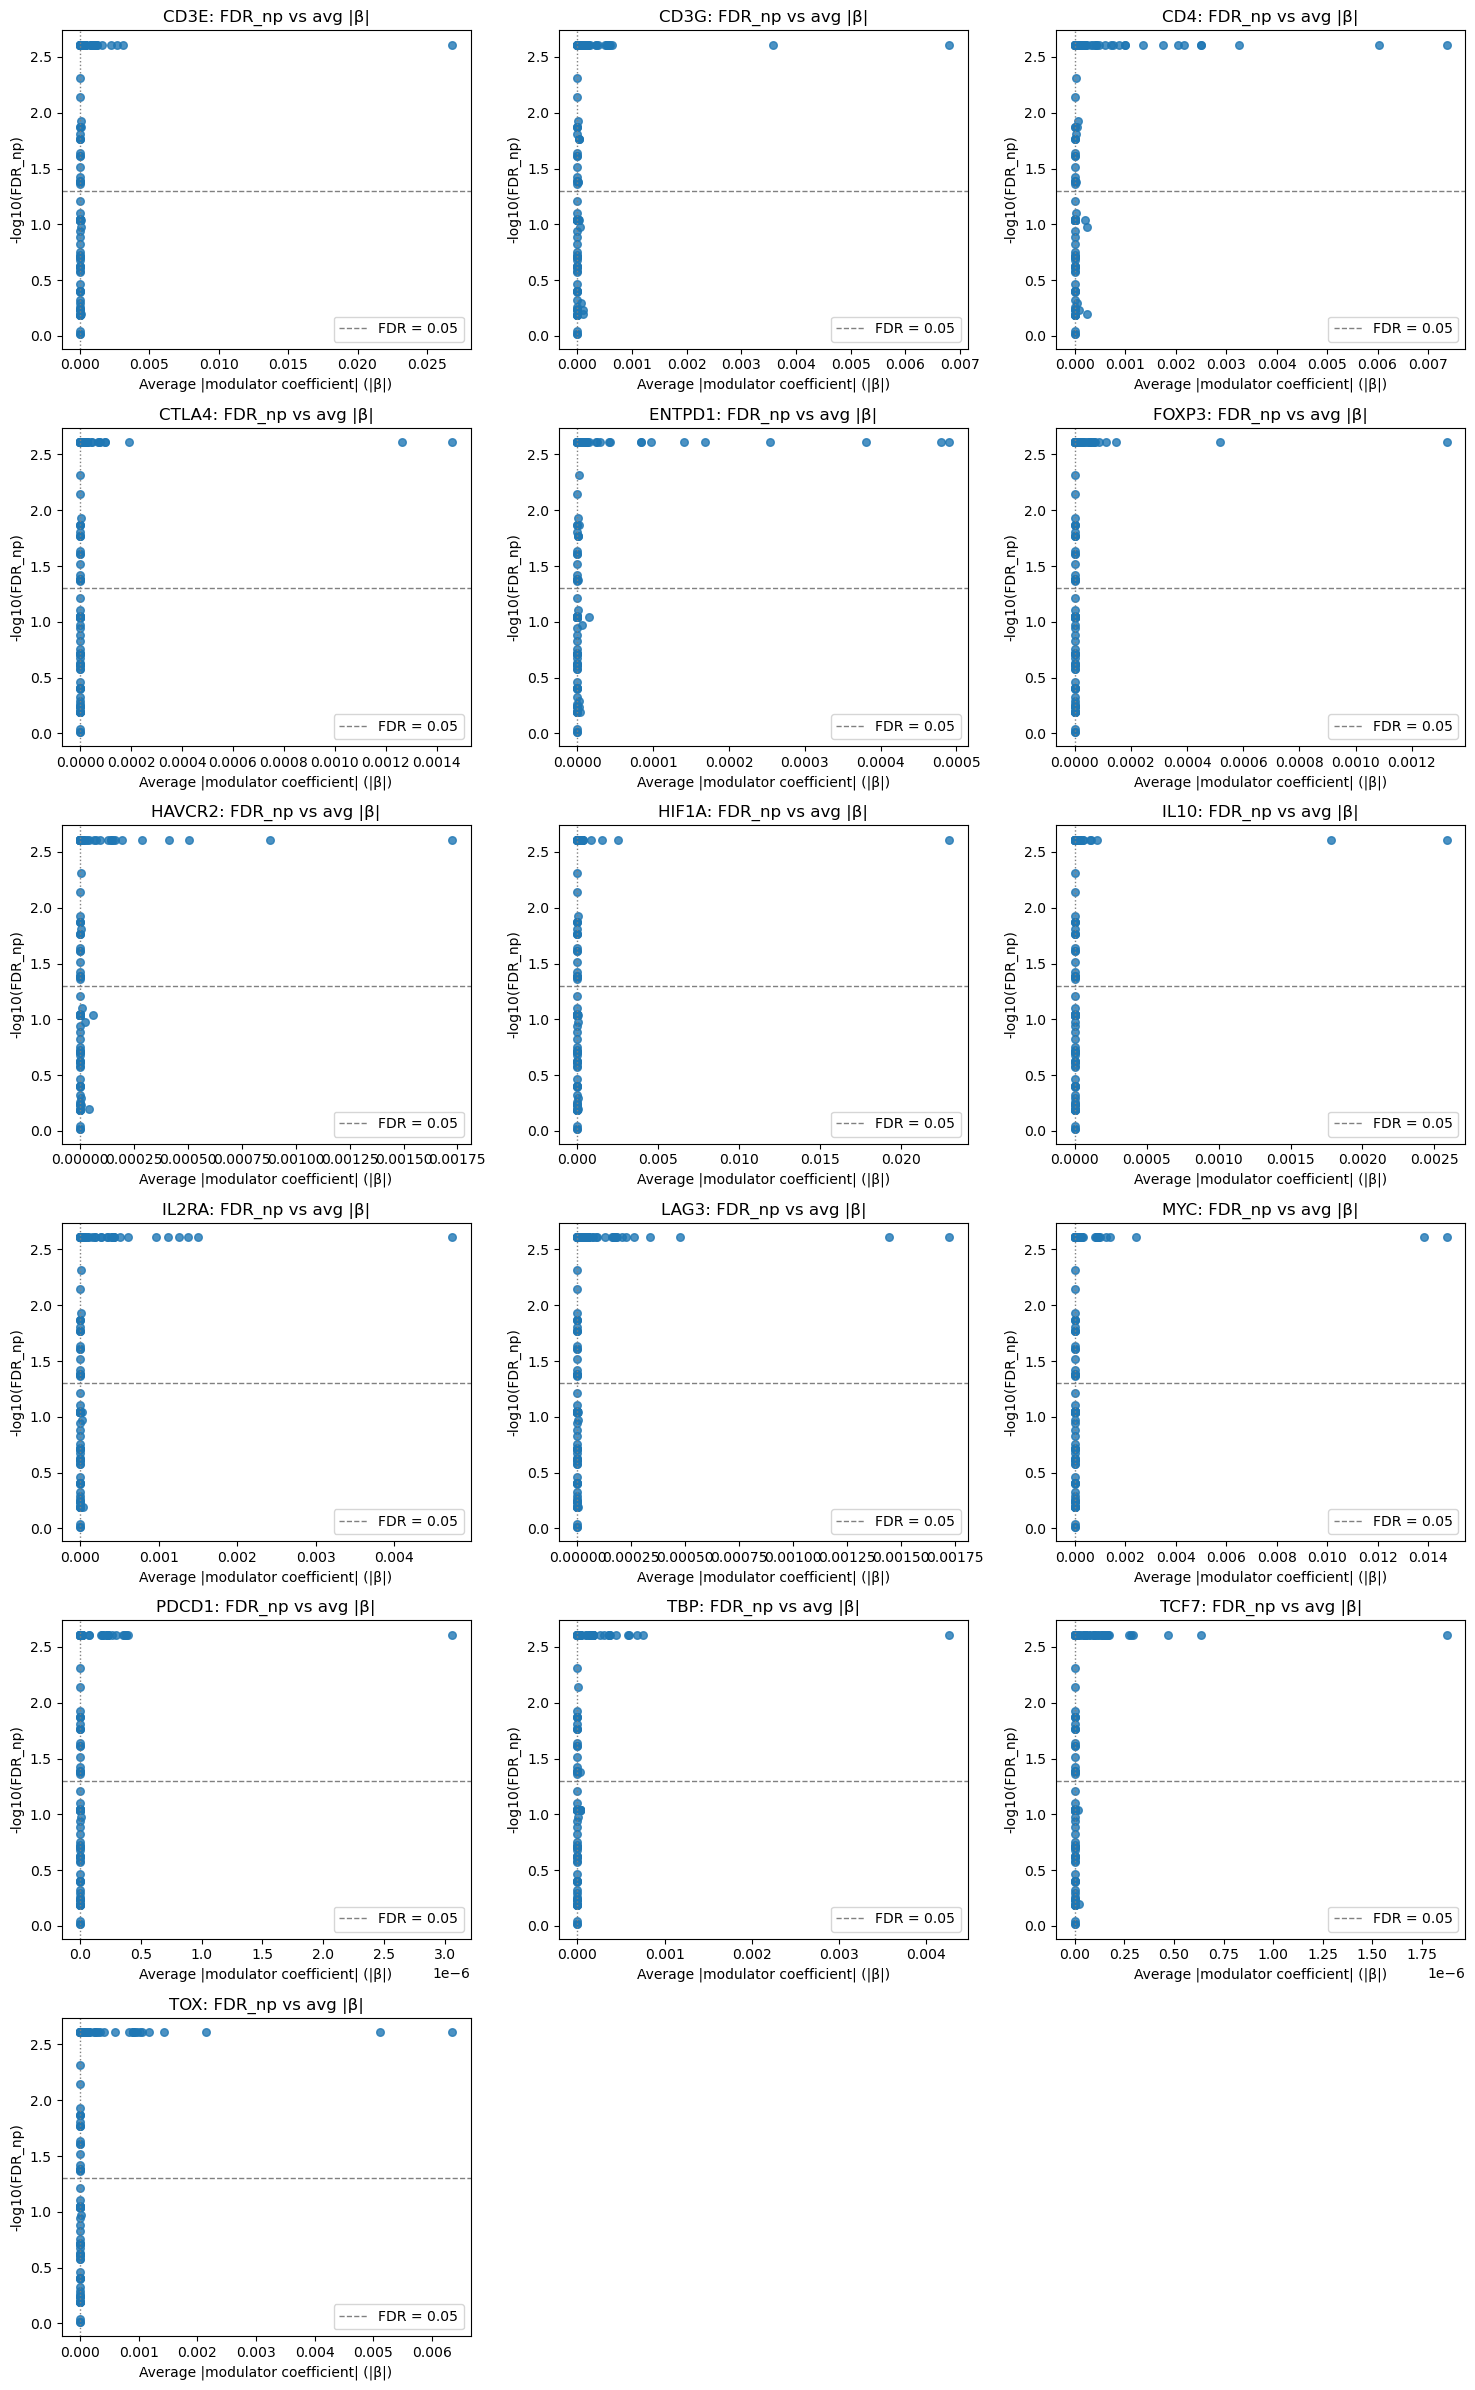

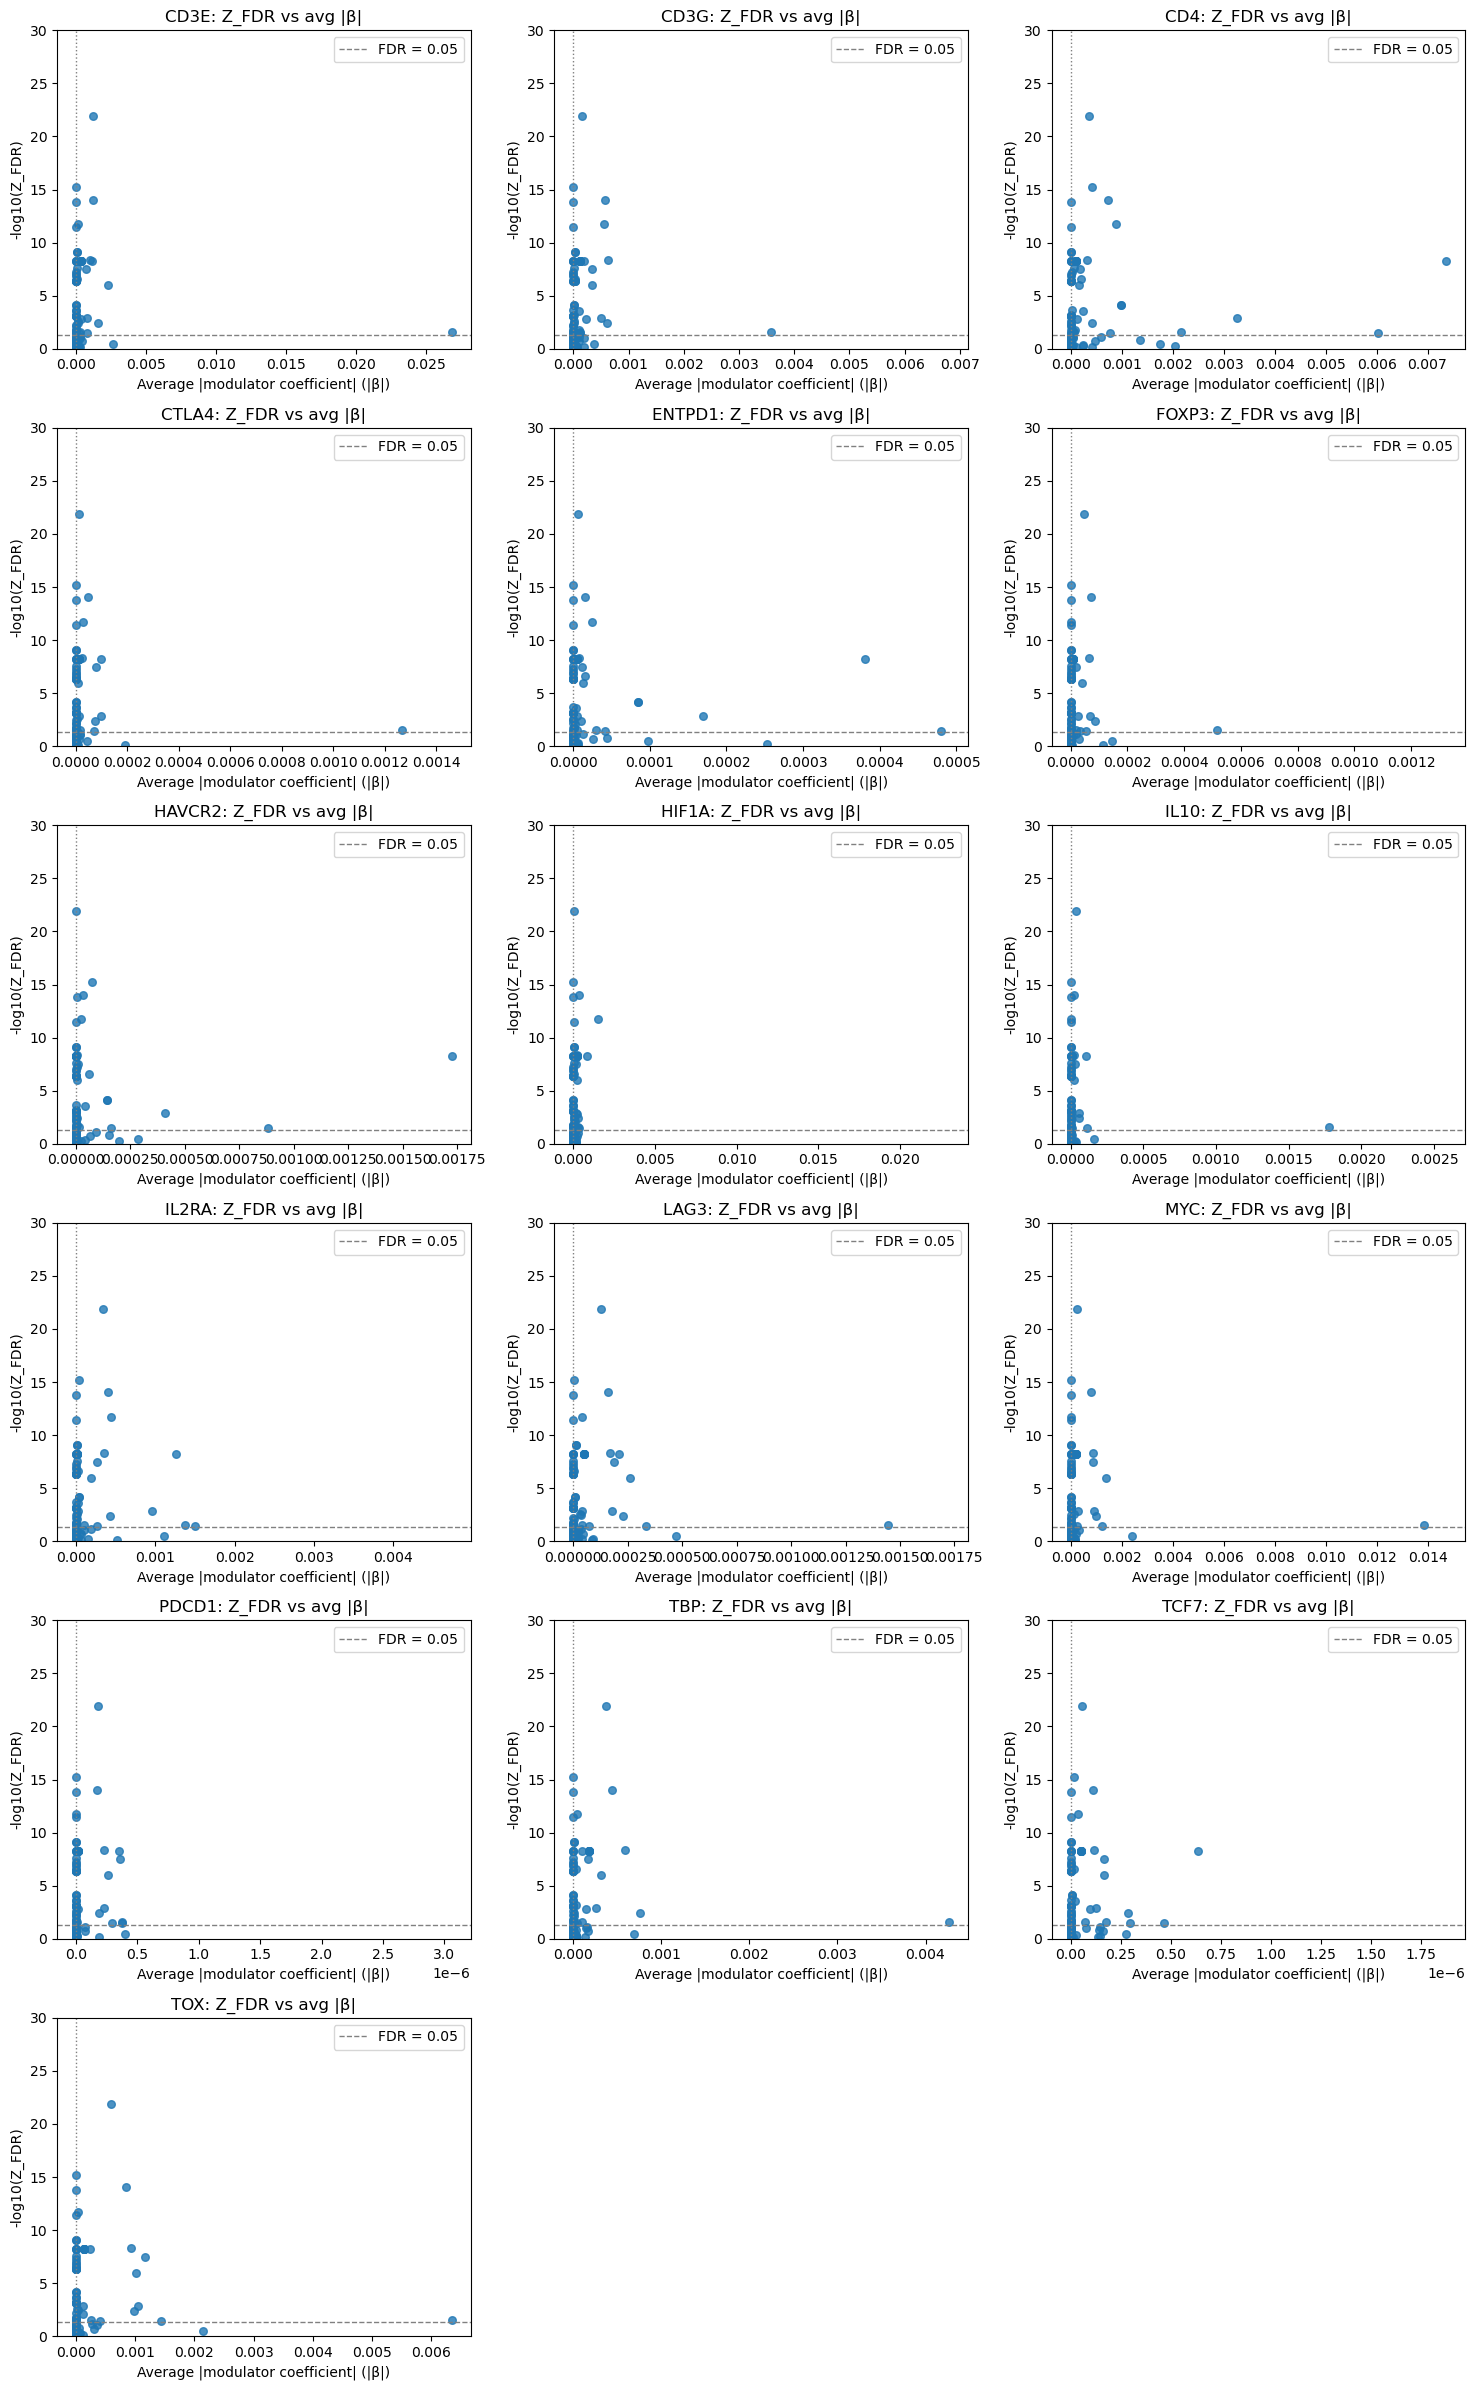

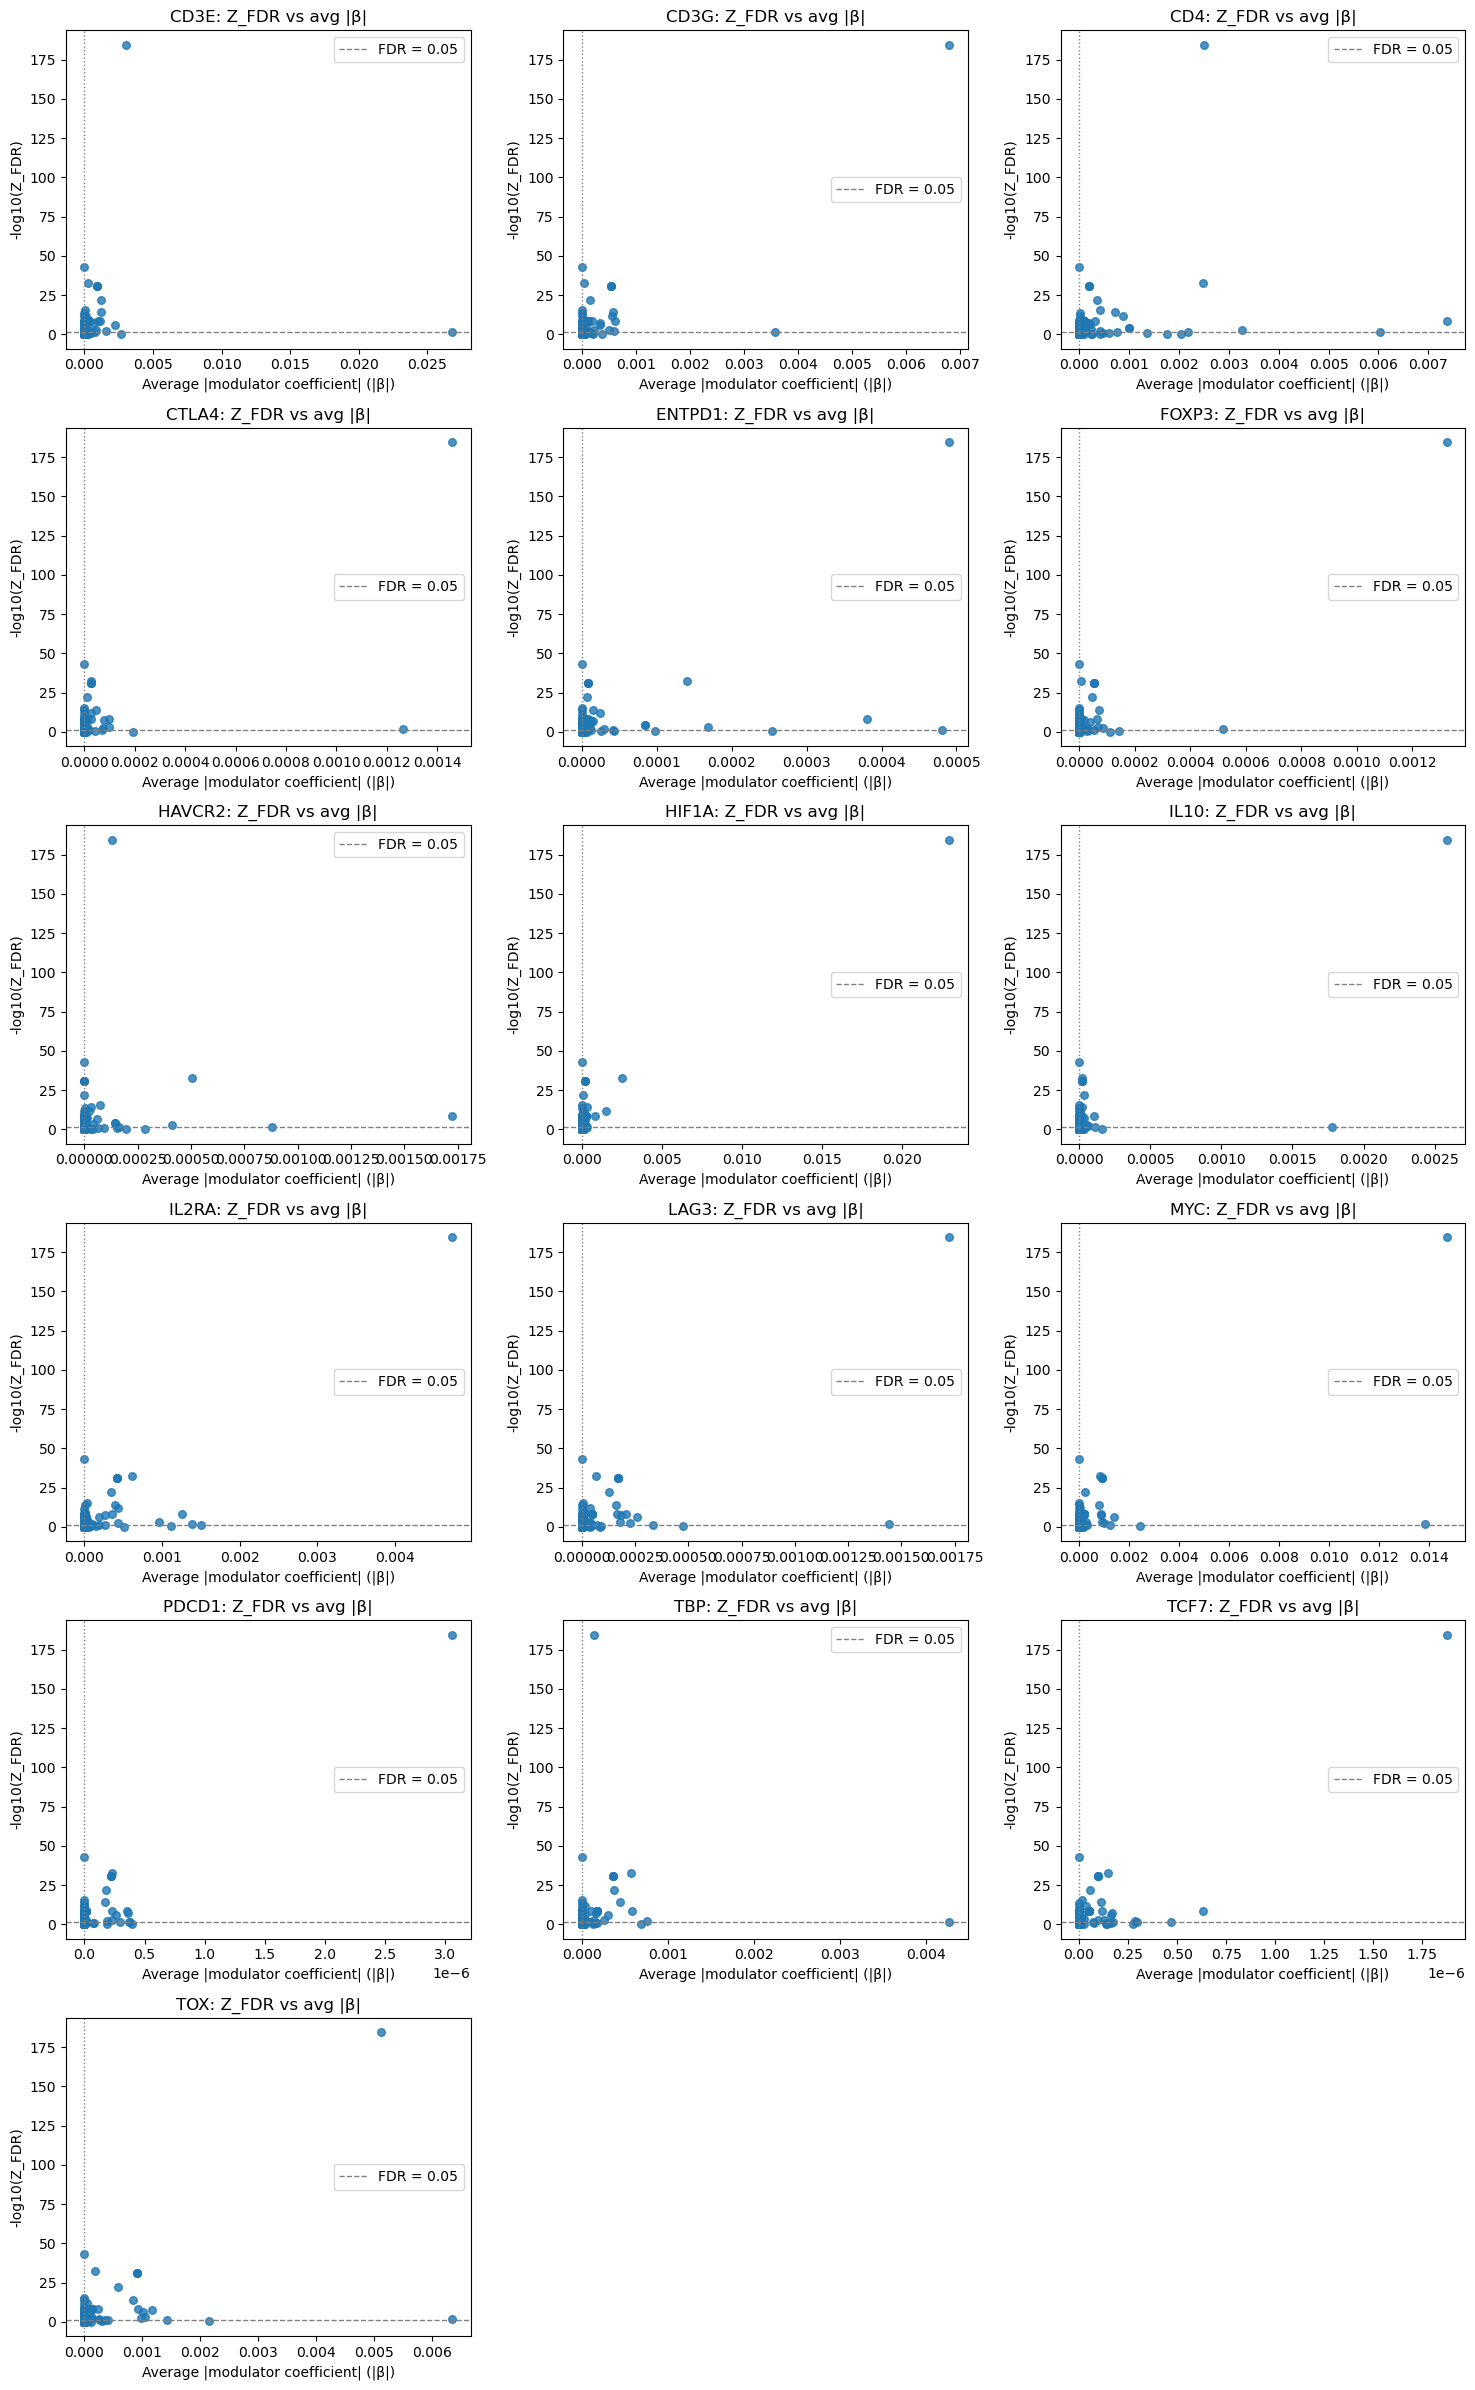

In [17]:
# all genes, Z_FDR, zoomed to the crowded region, no labels
plot_betas_grid(dfs, fdr_col='FDR_np', labels=False)
plt.show()

plot_betas_grid(dfs, fdr_col='Z_FDR', ylim=(0, 30), labels=False)
plt.show()

plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False)
plt.show()



# # a single gene still works with your existing call
# plot_betas(dfs['CD3E'], fdr_col='FDR_np', labels=False, TARGET_GENE='CD3E')
# plt.tight_layout()
# plt.show()

Dataset: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_1


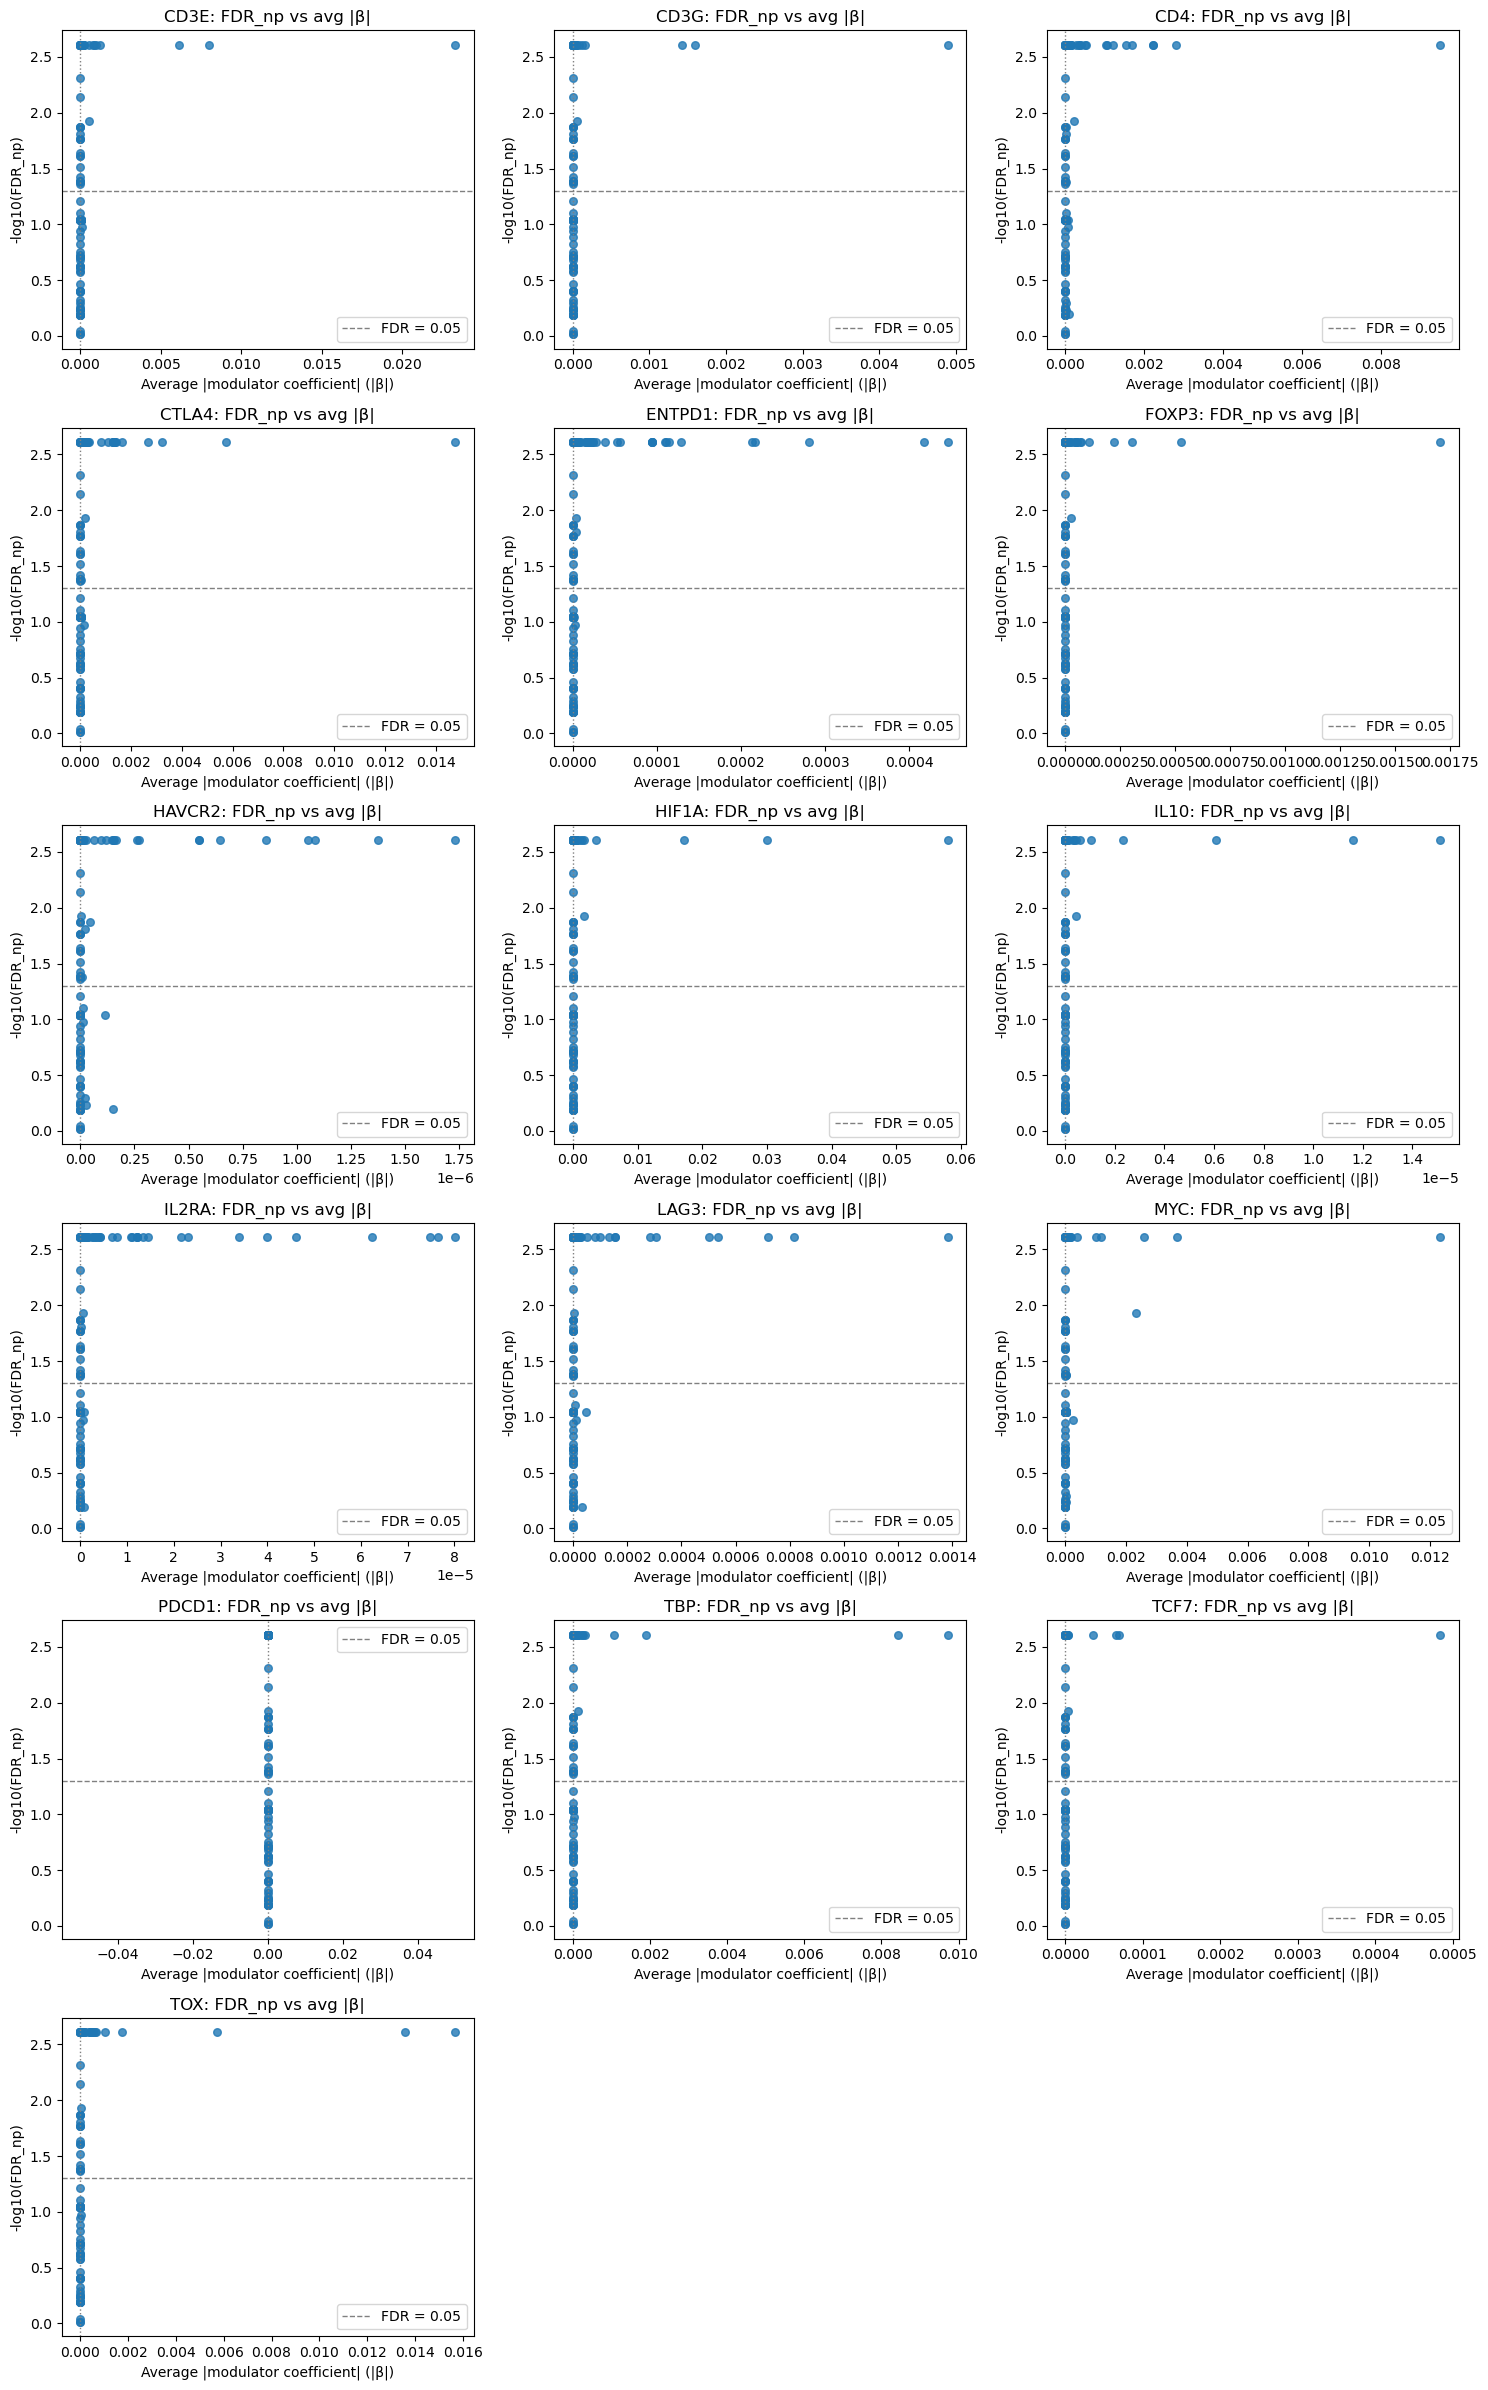

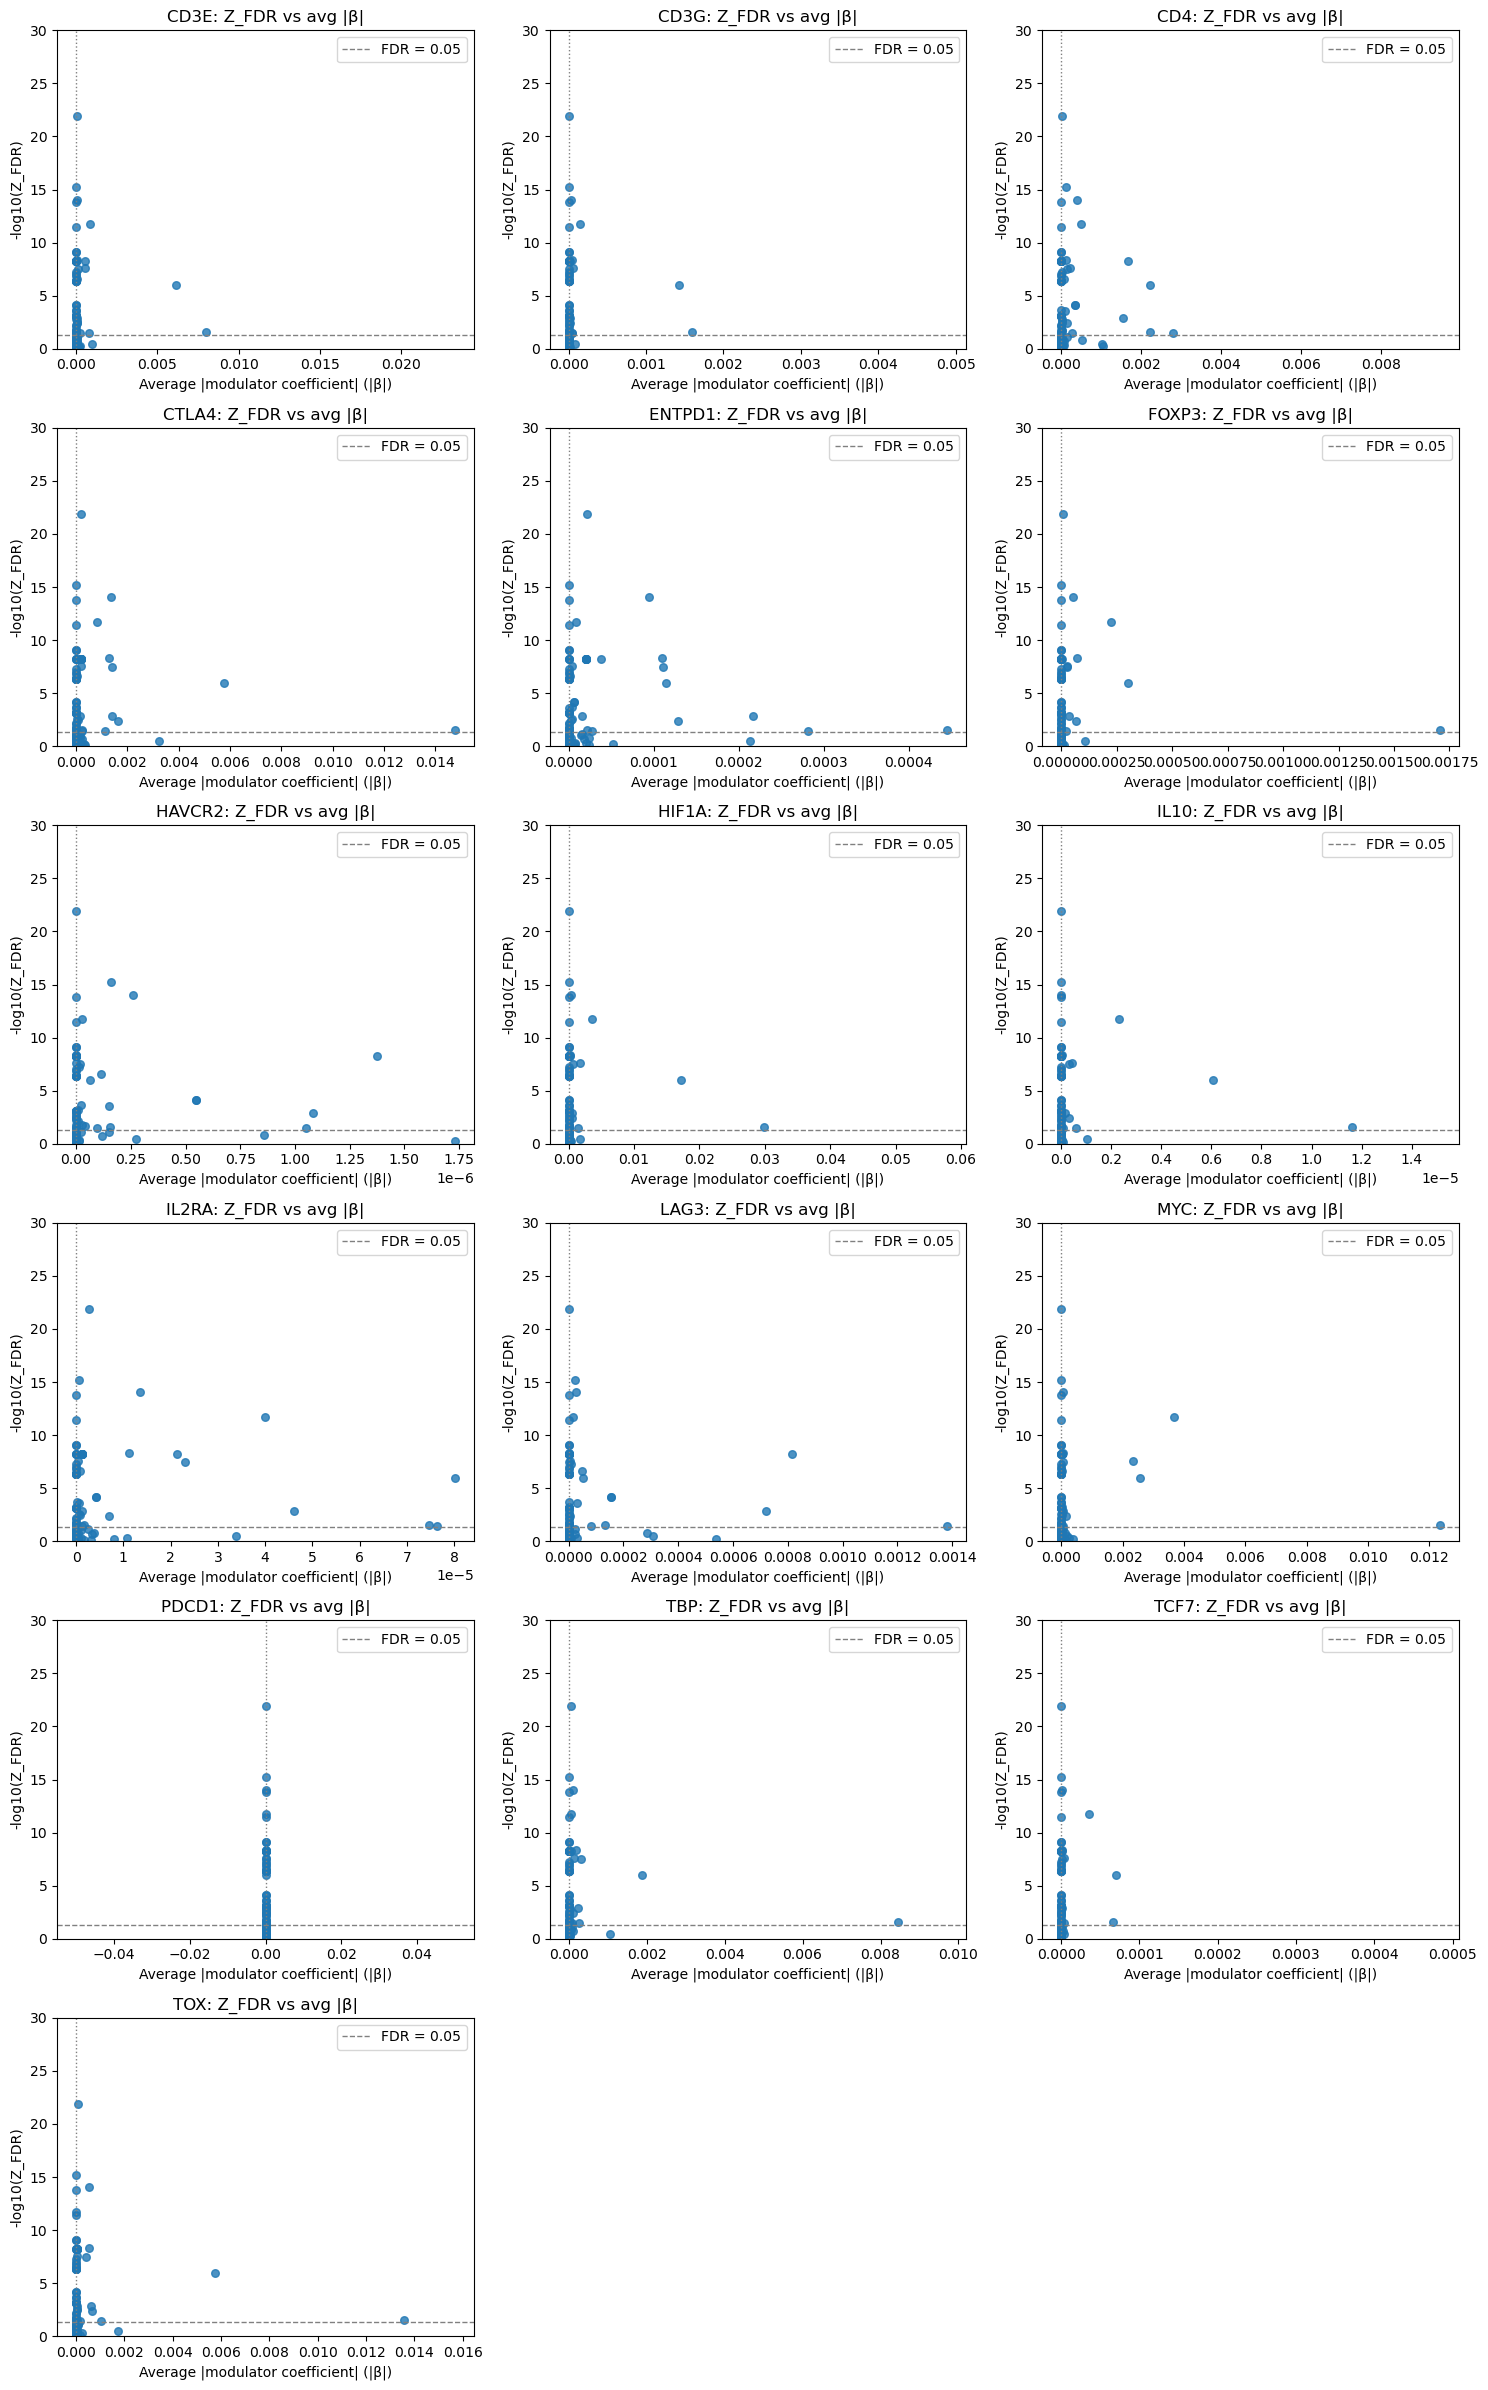

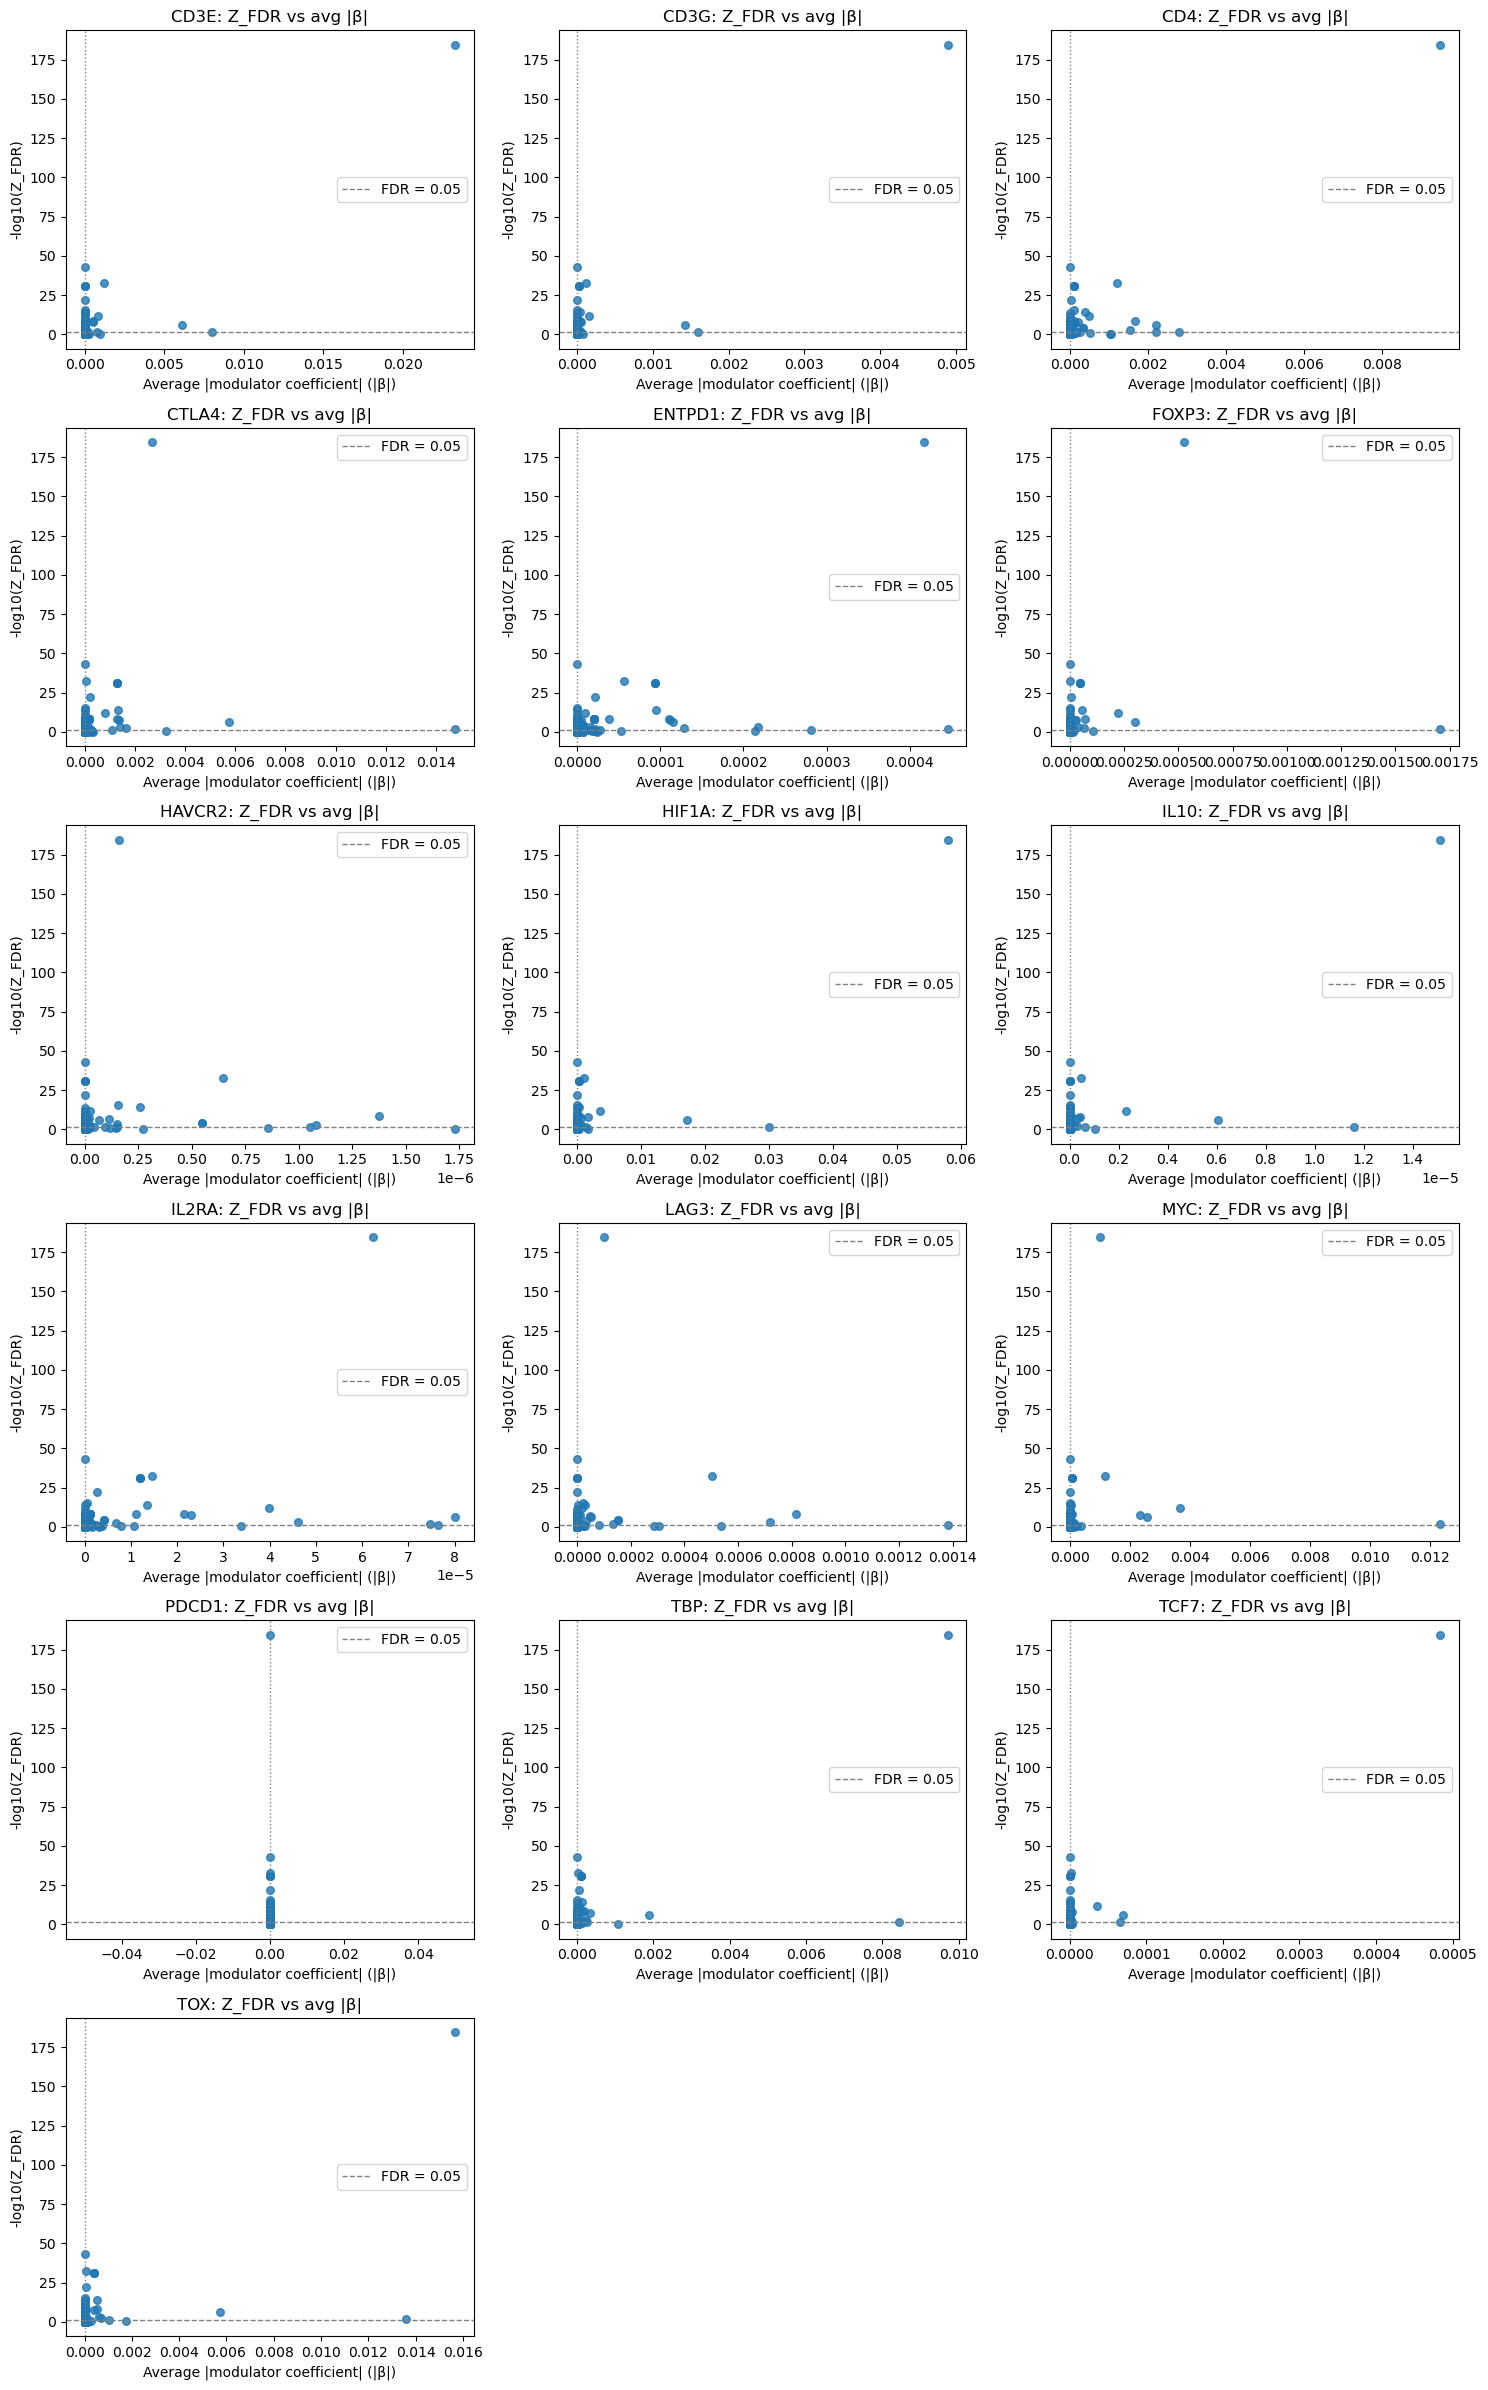

Dataset: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_2


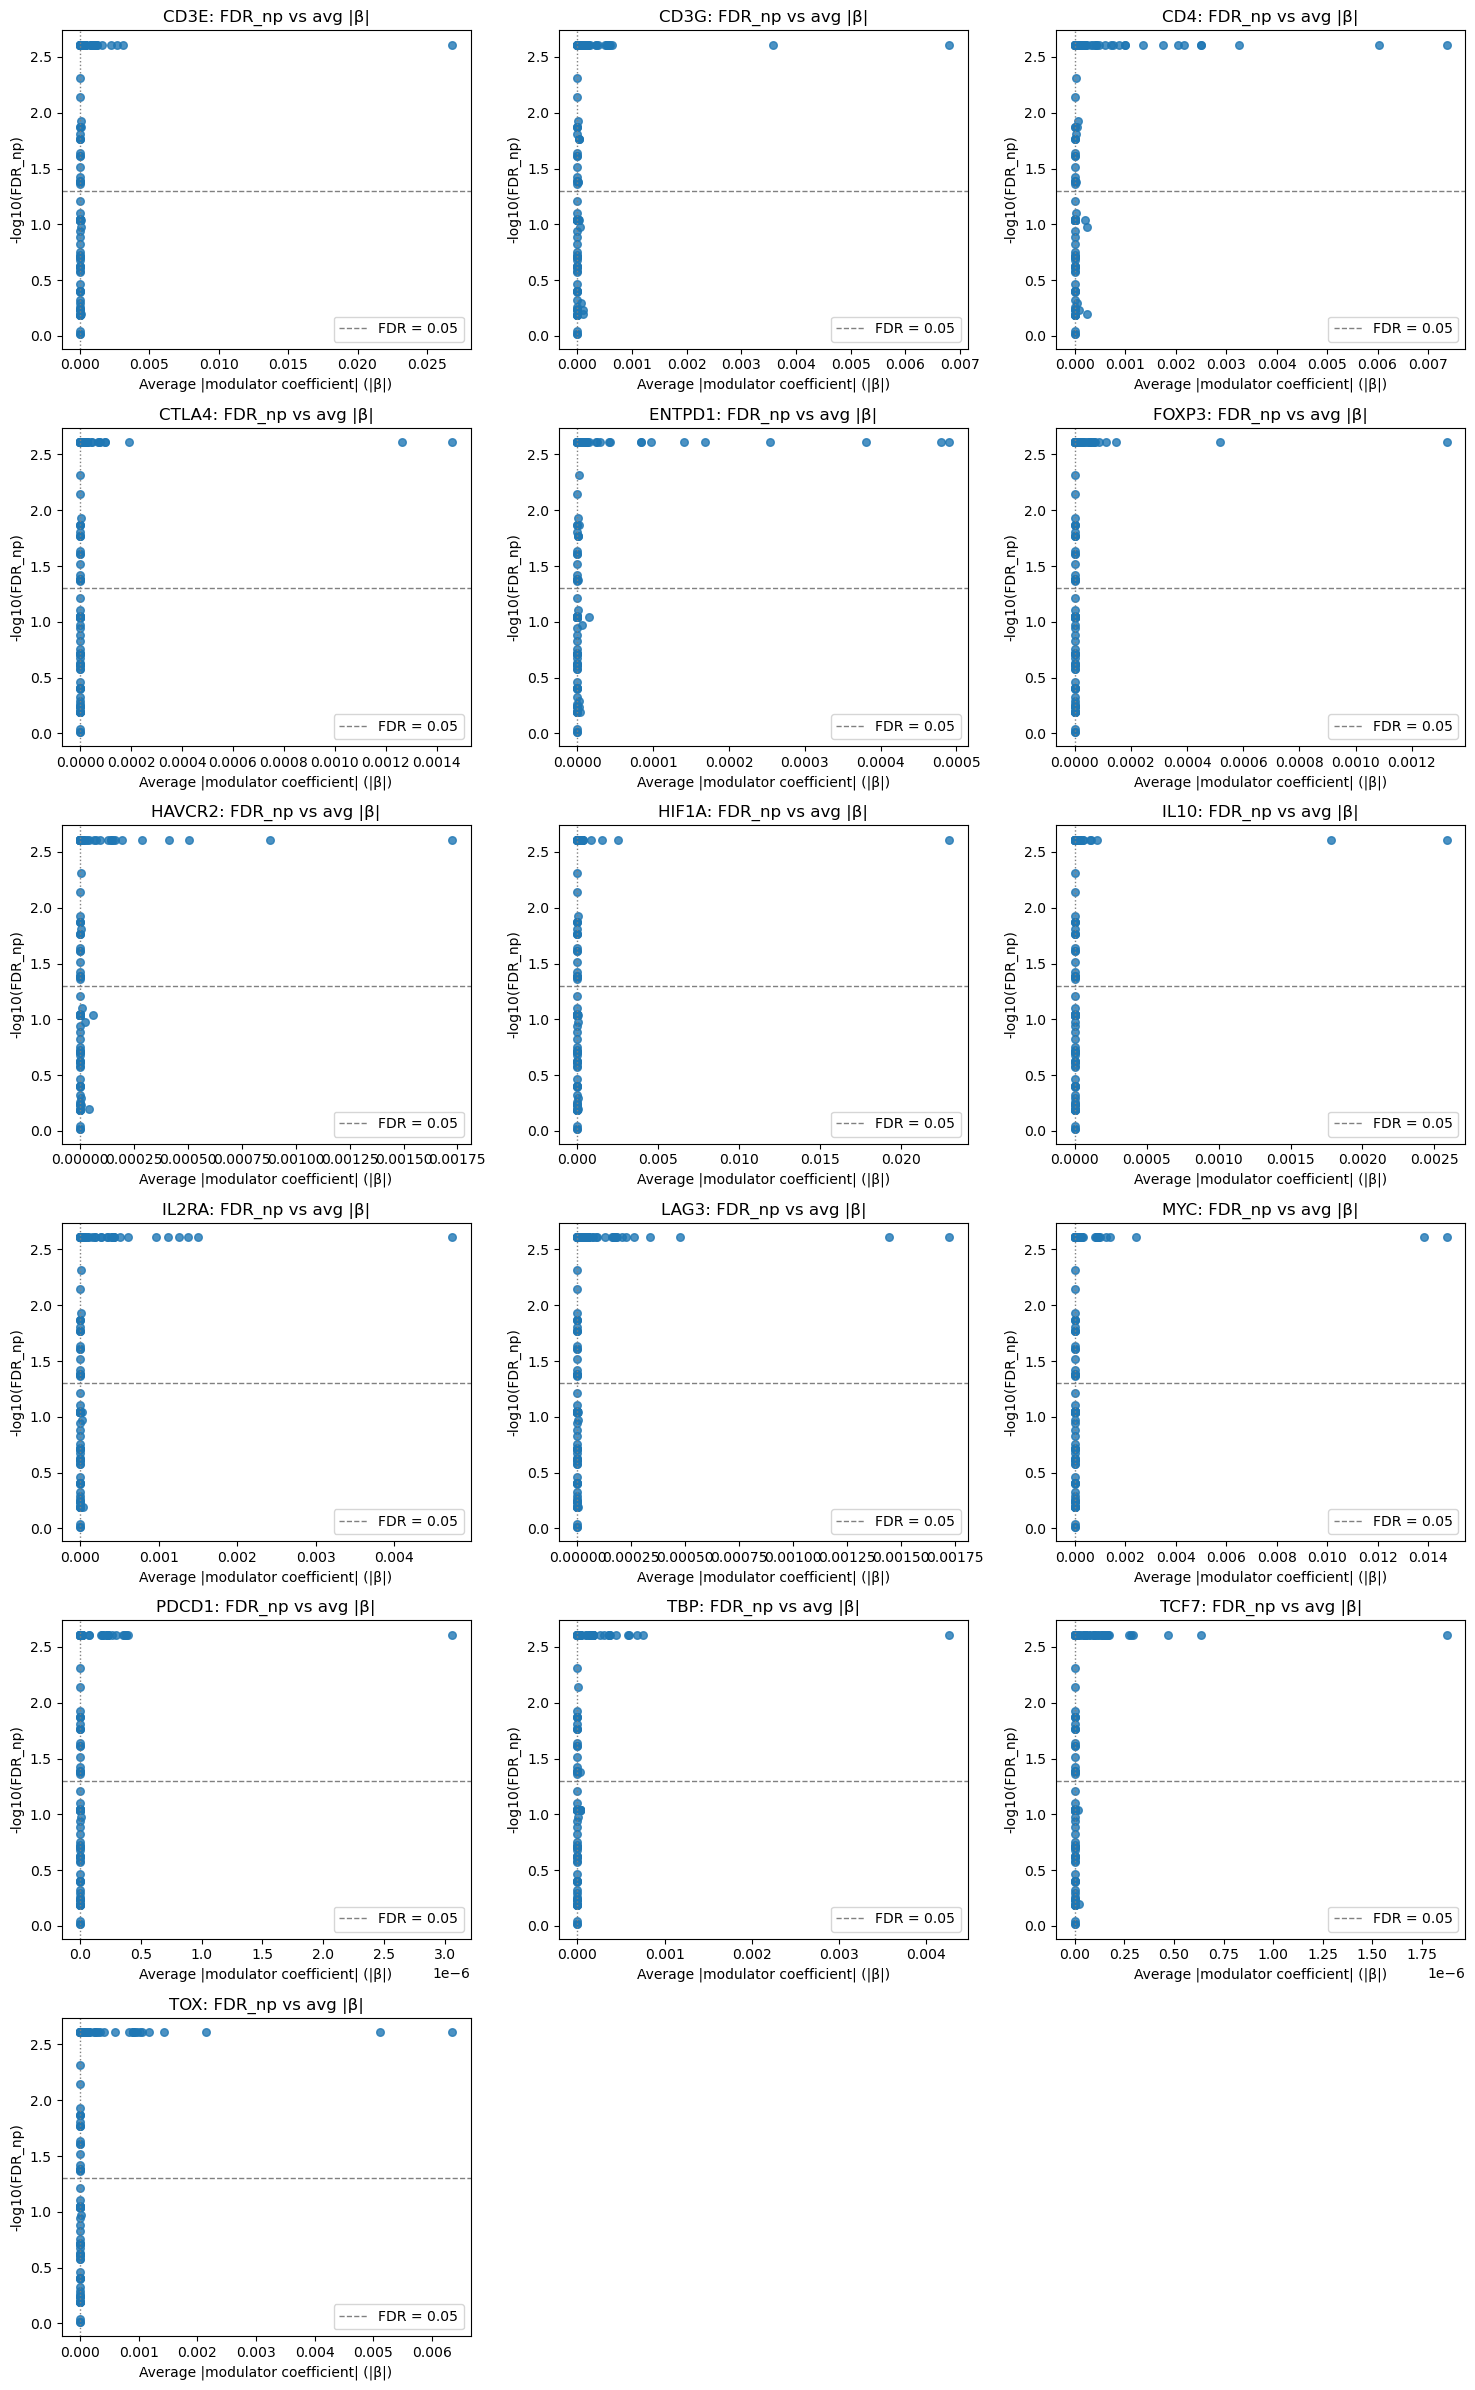

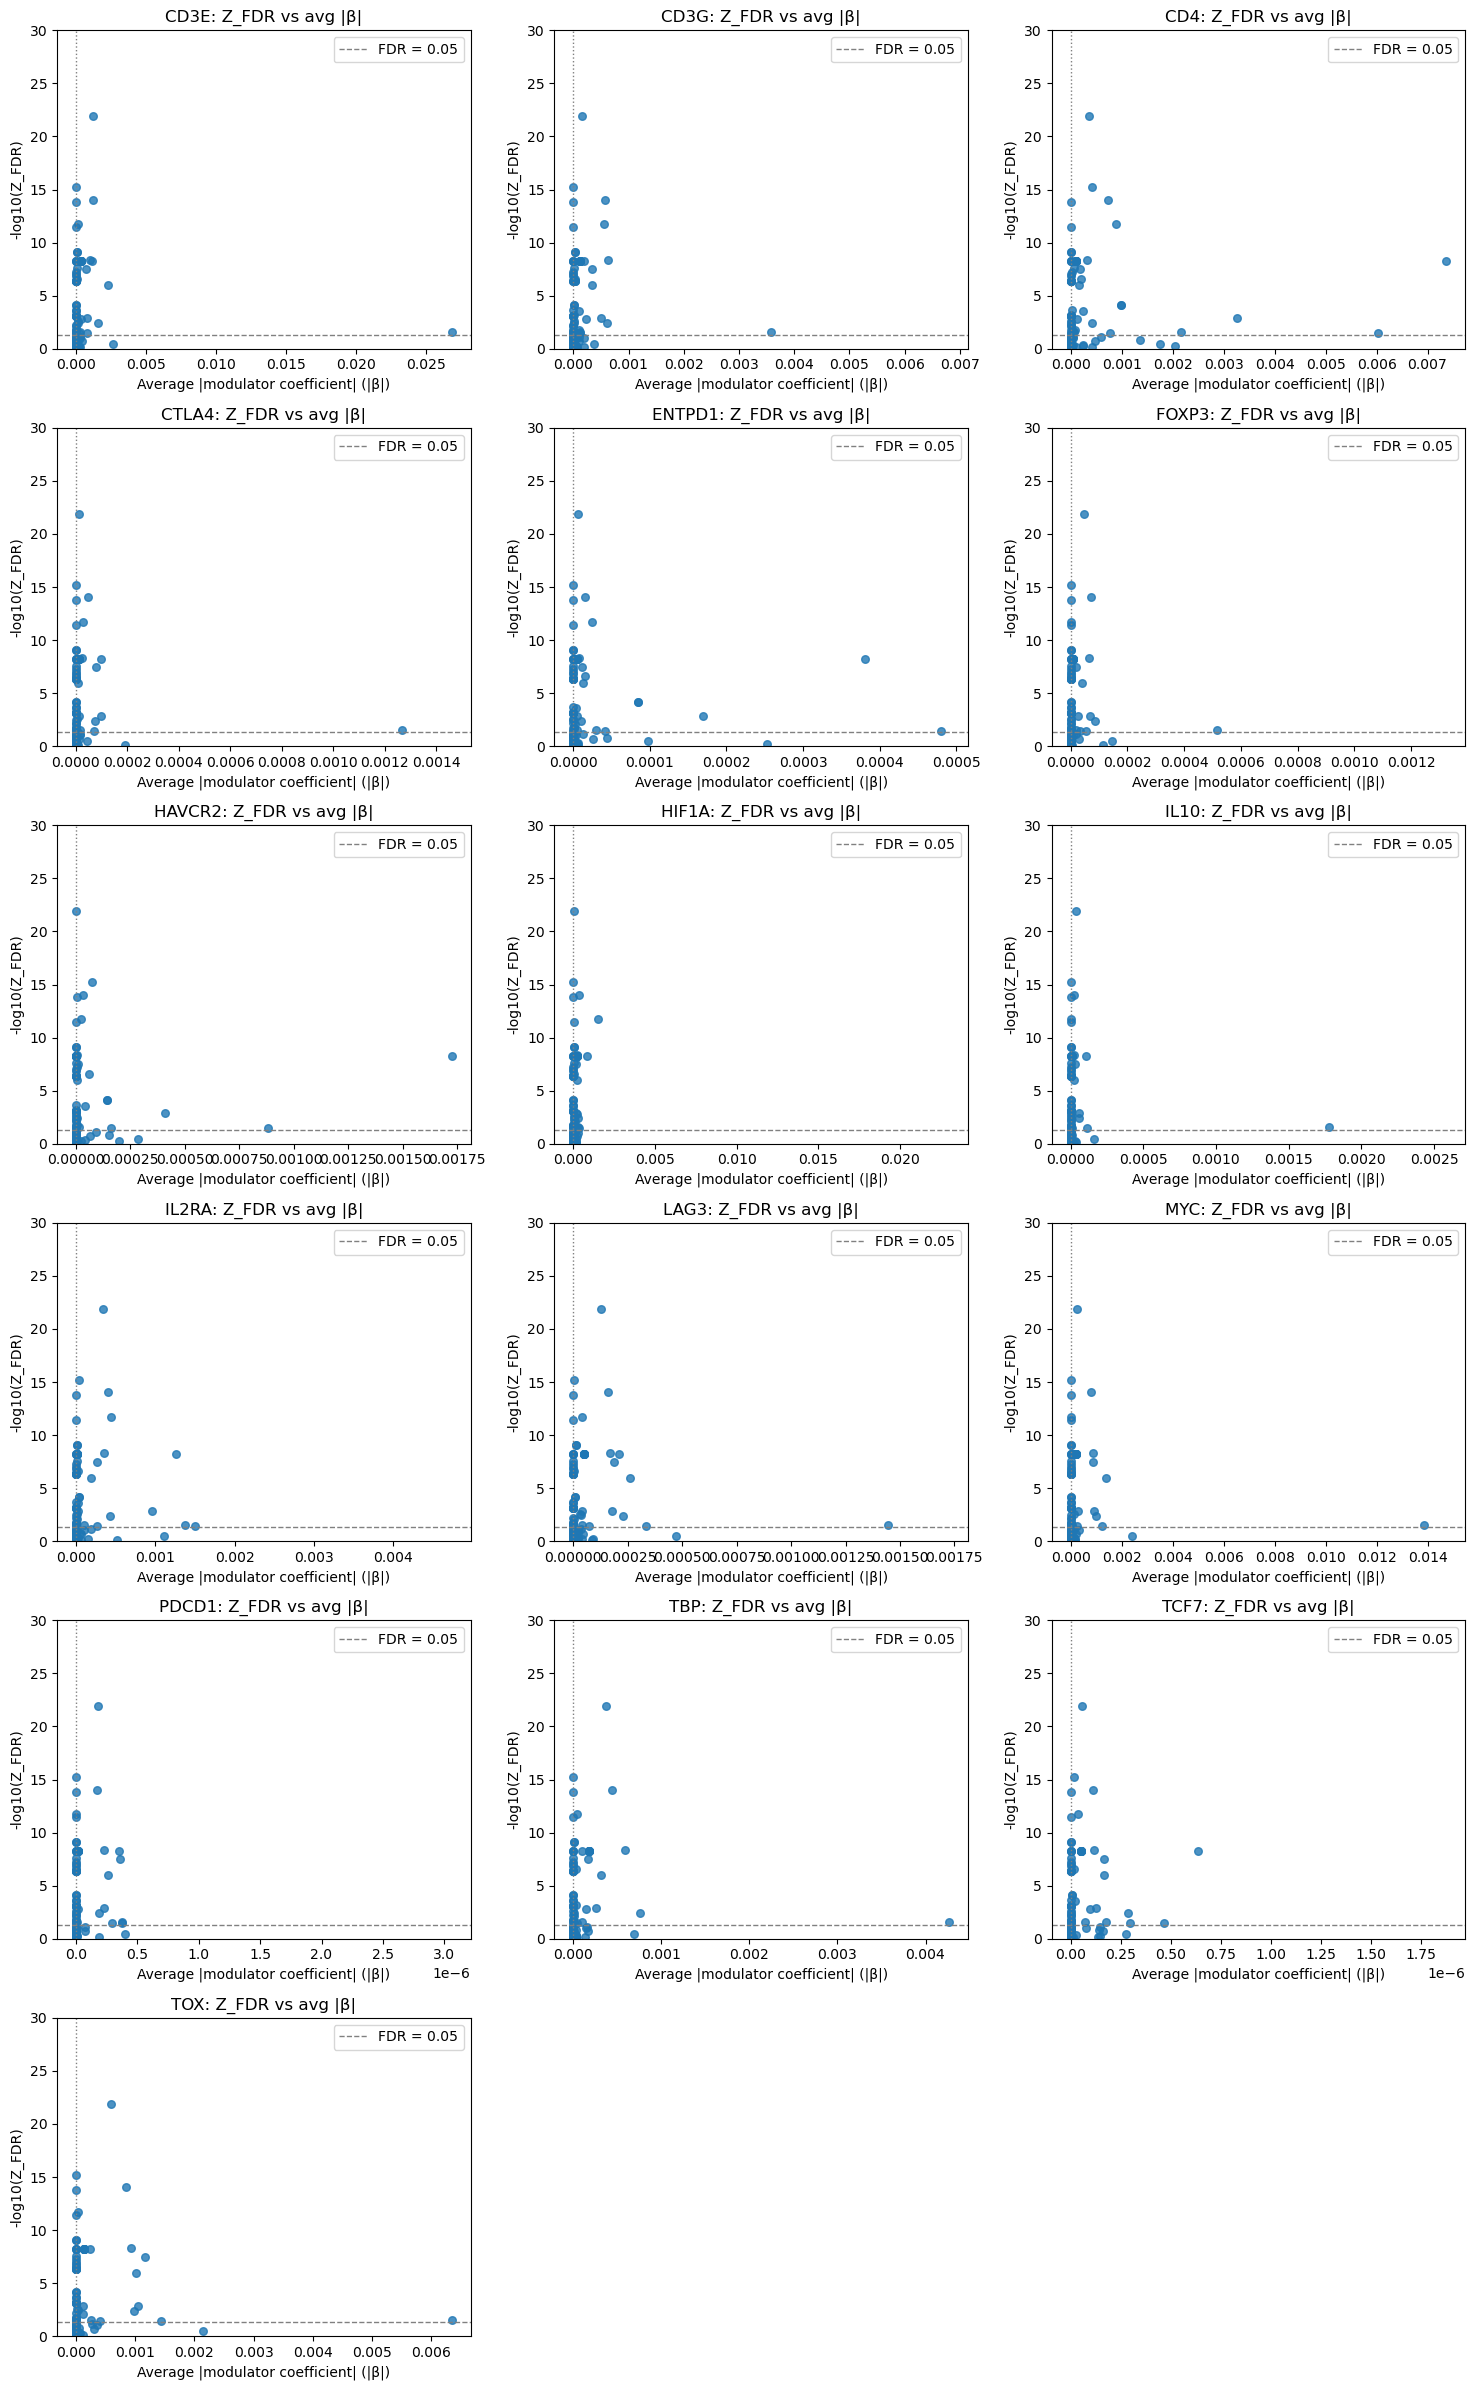

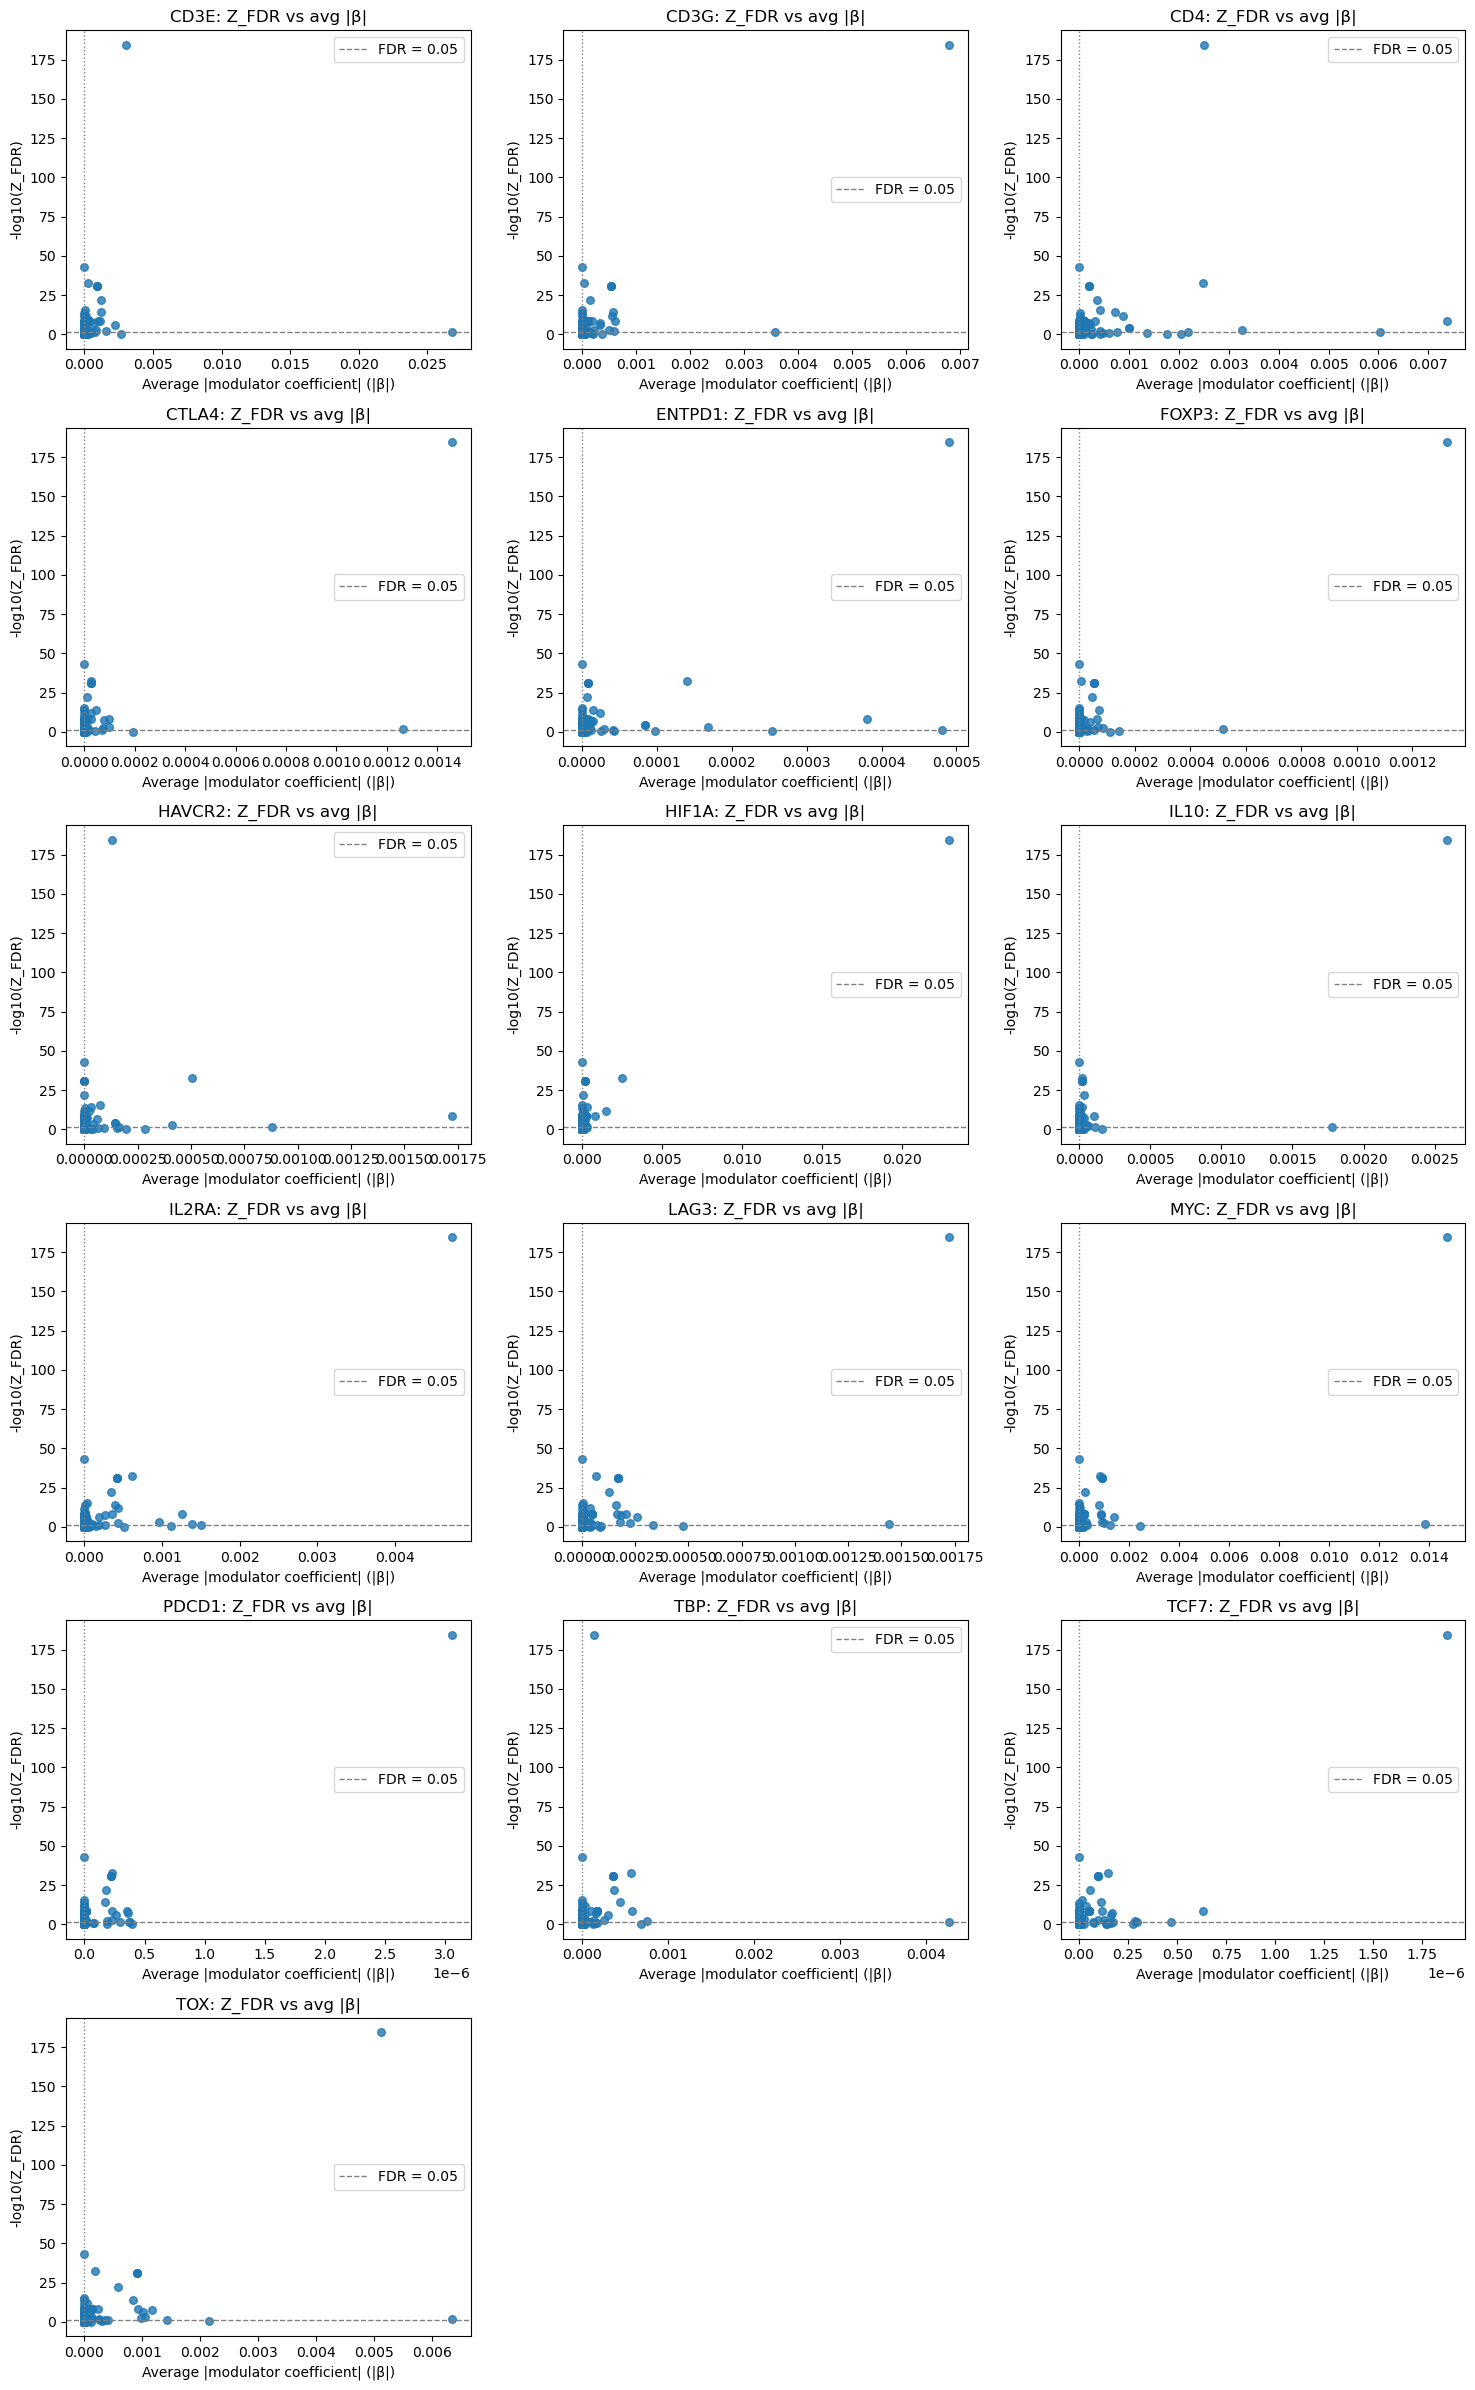

Dataset: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_3


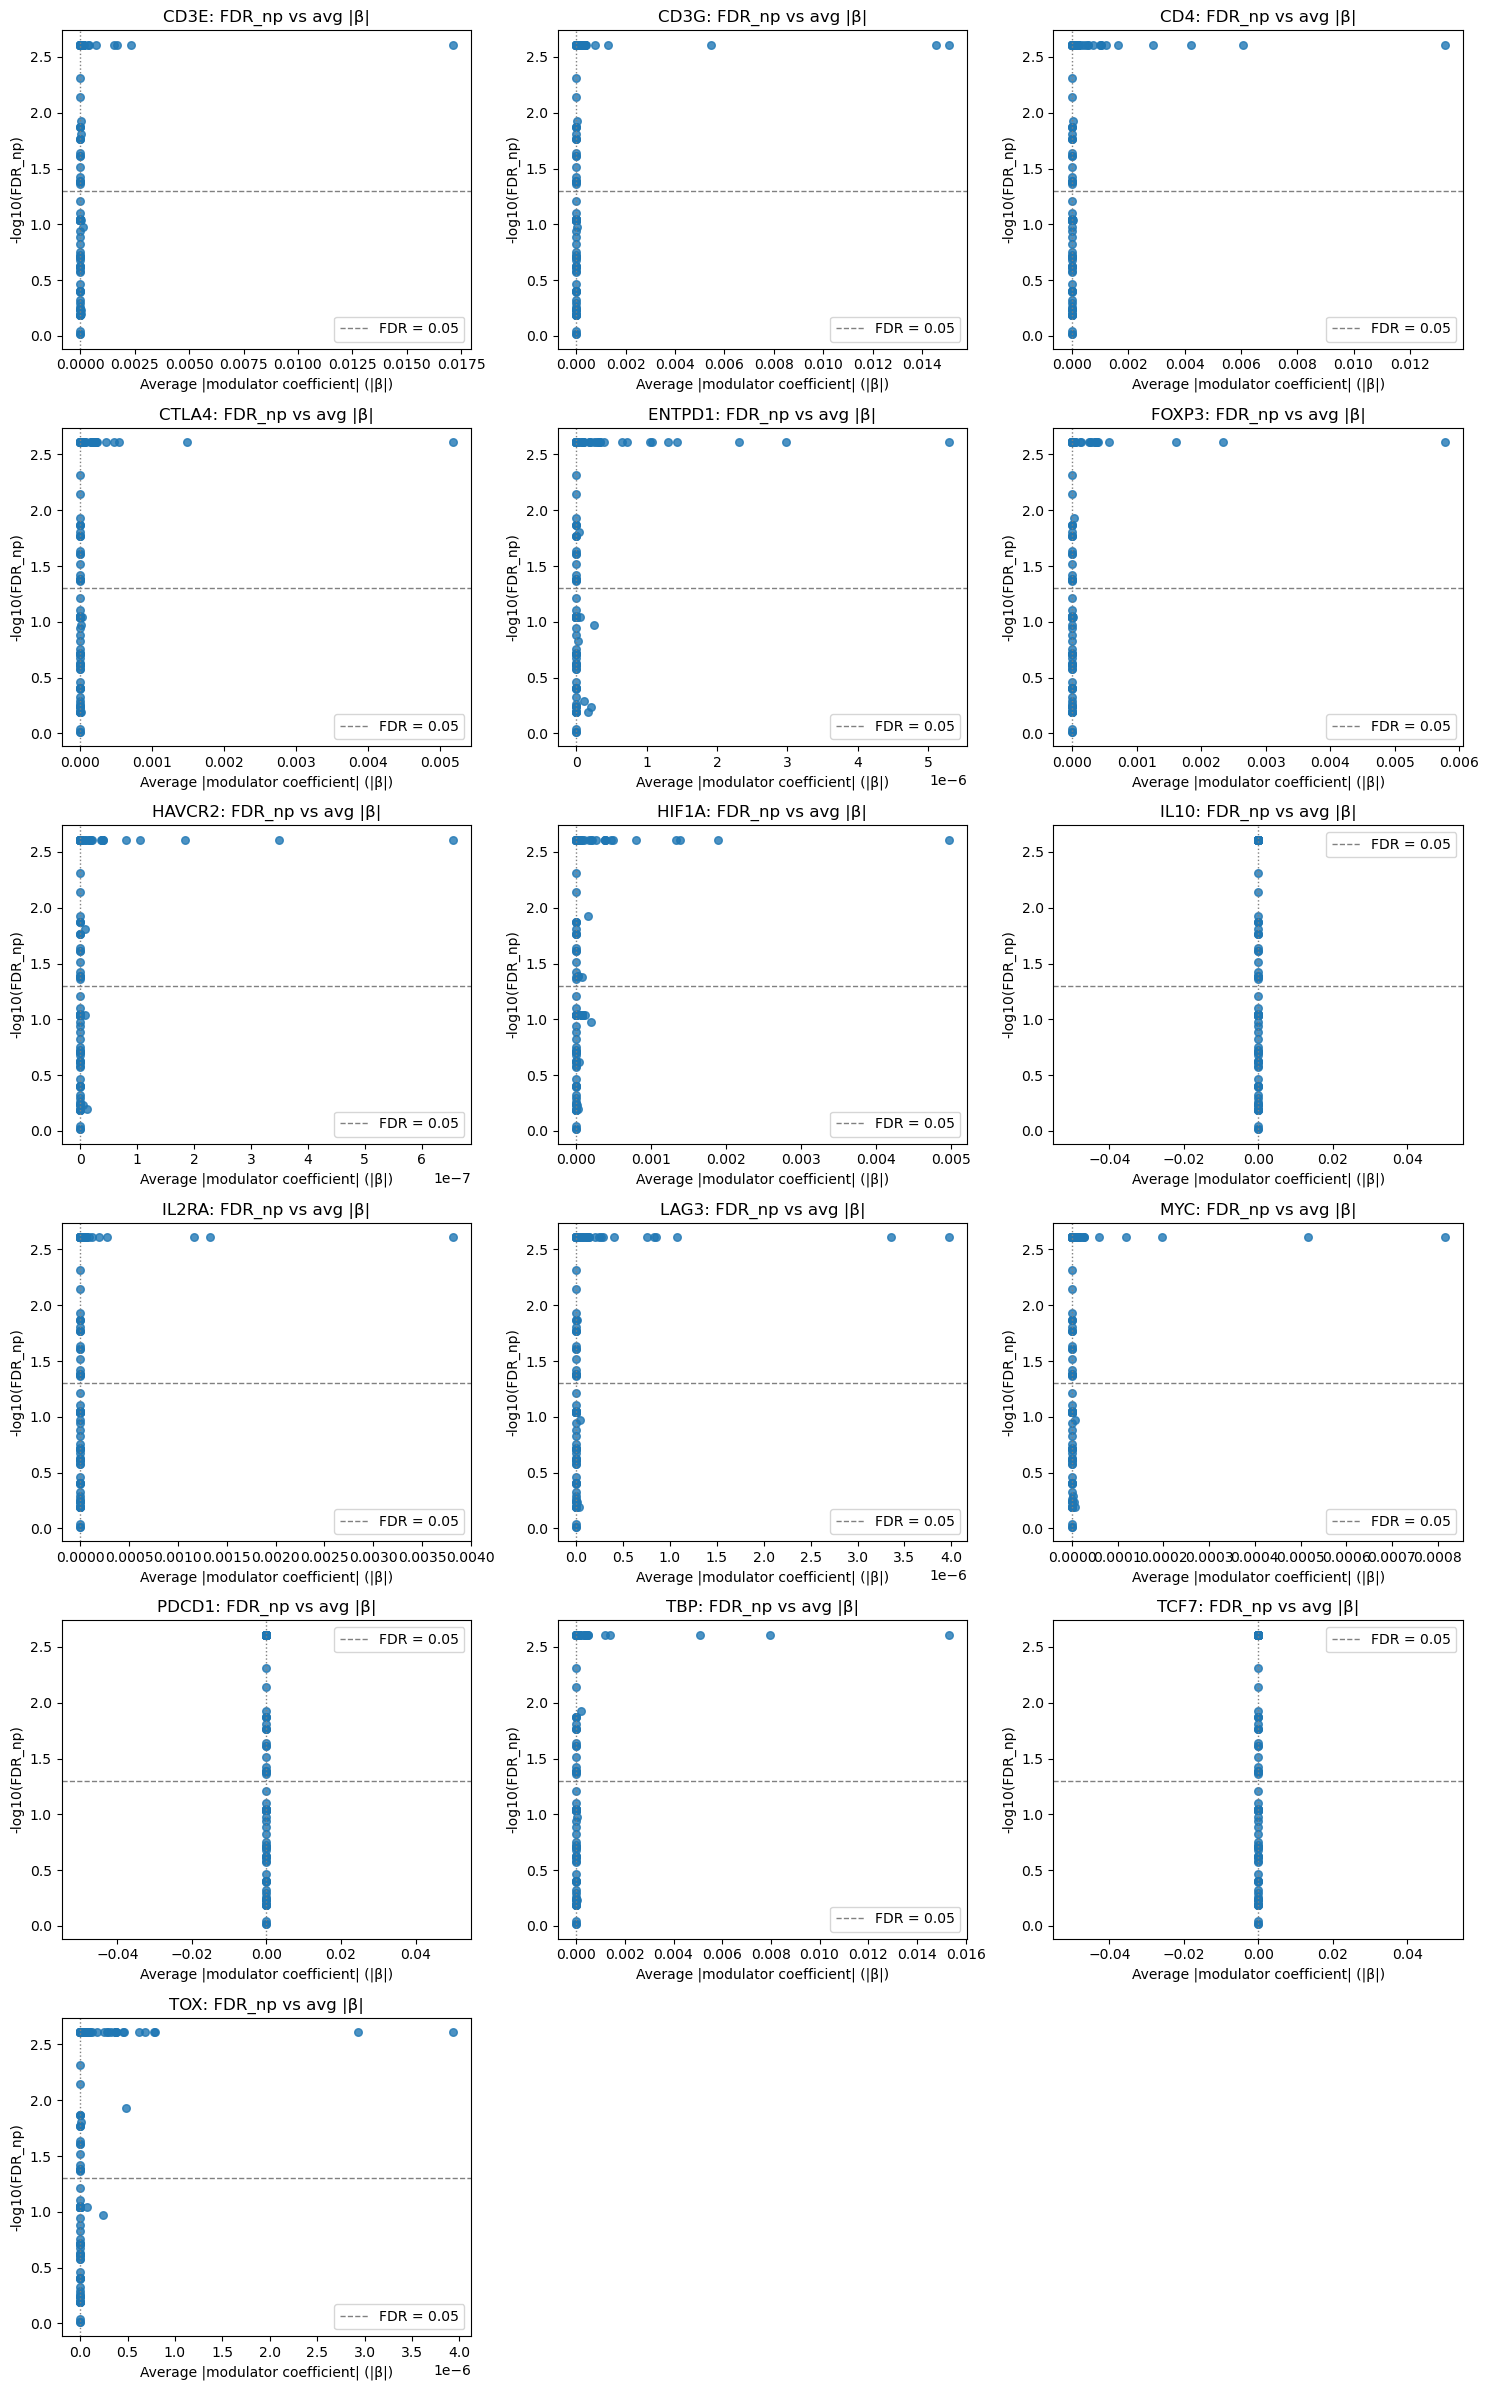

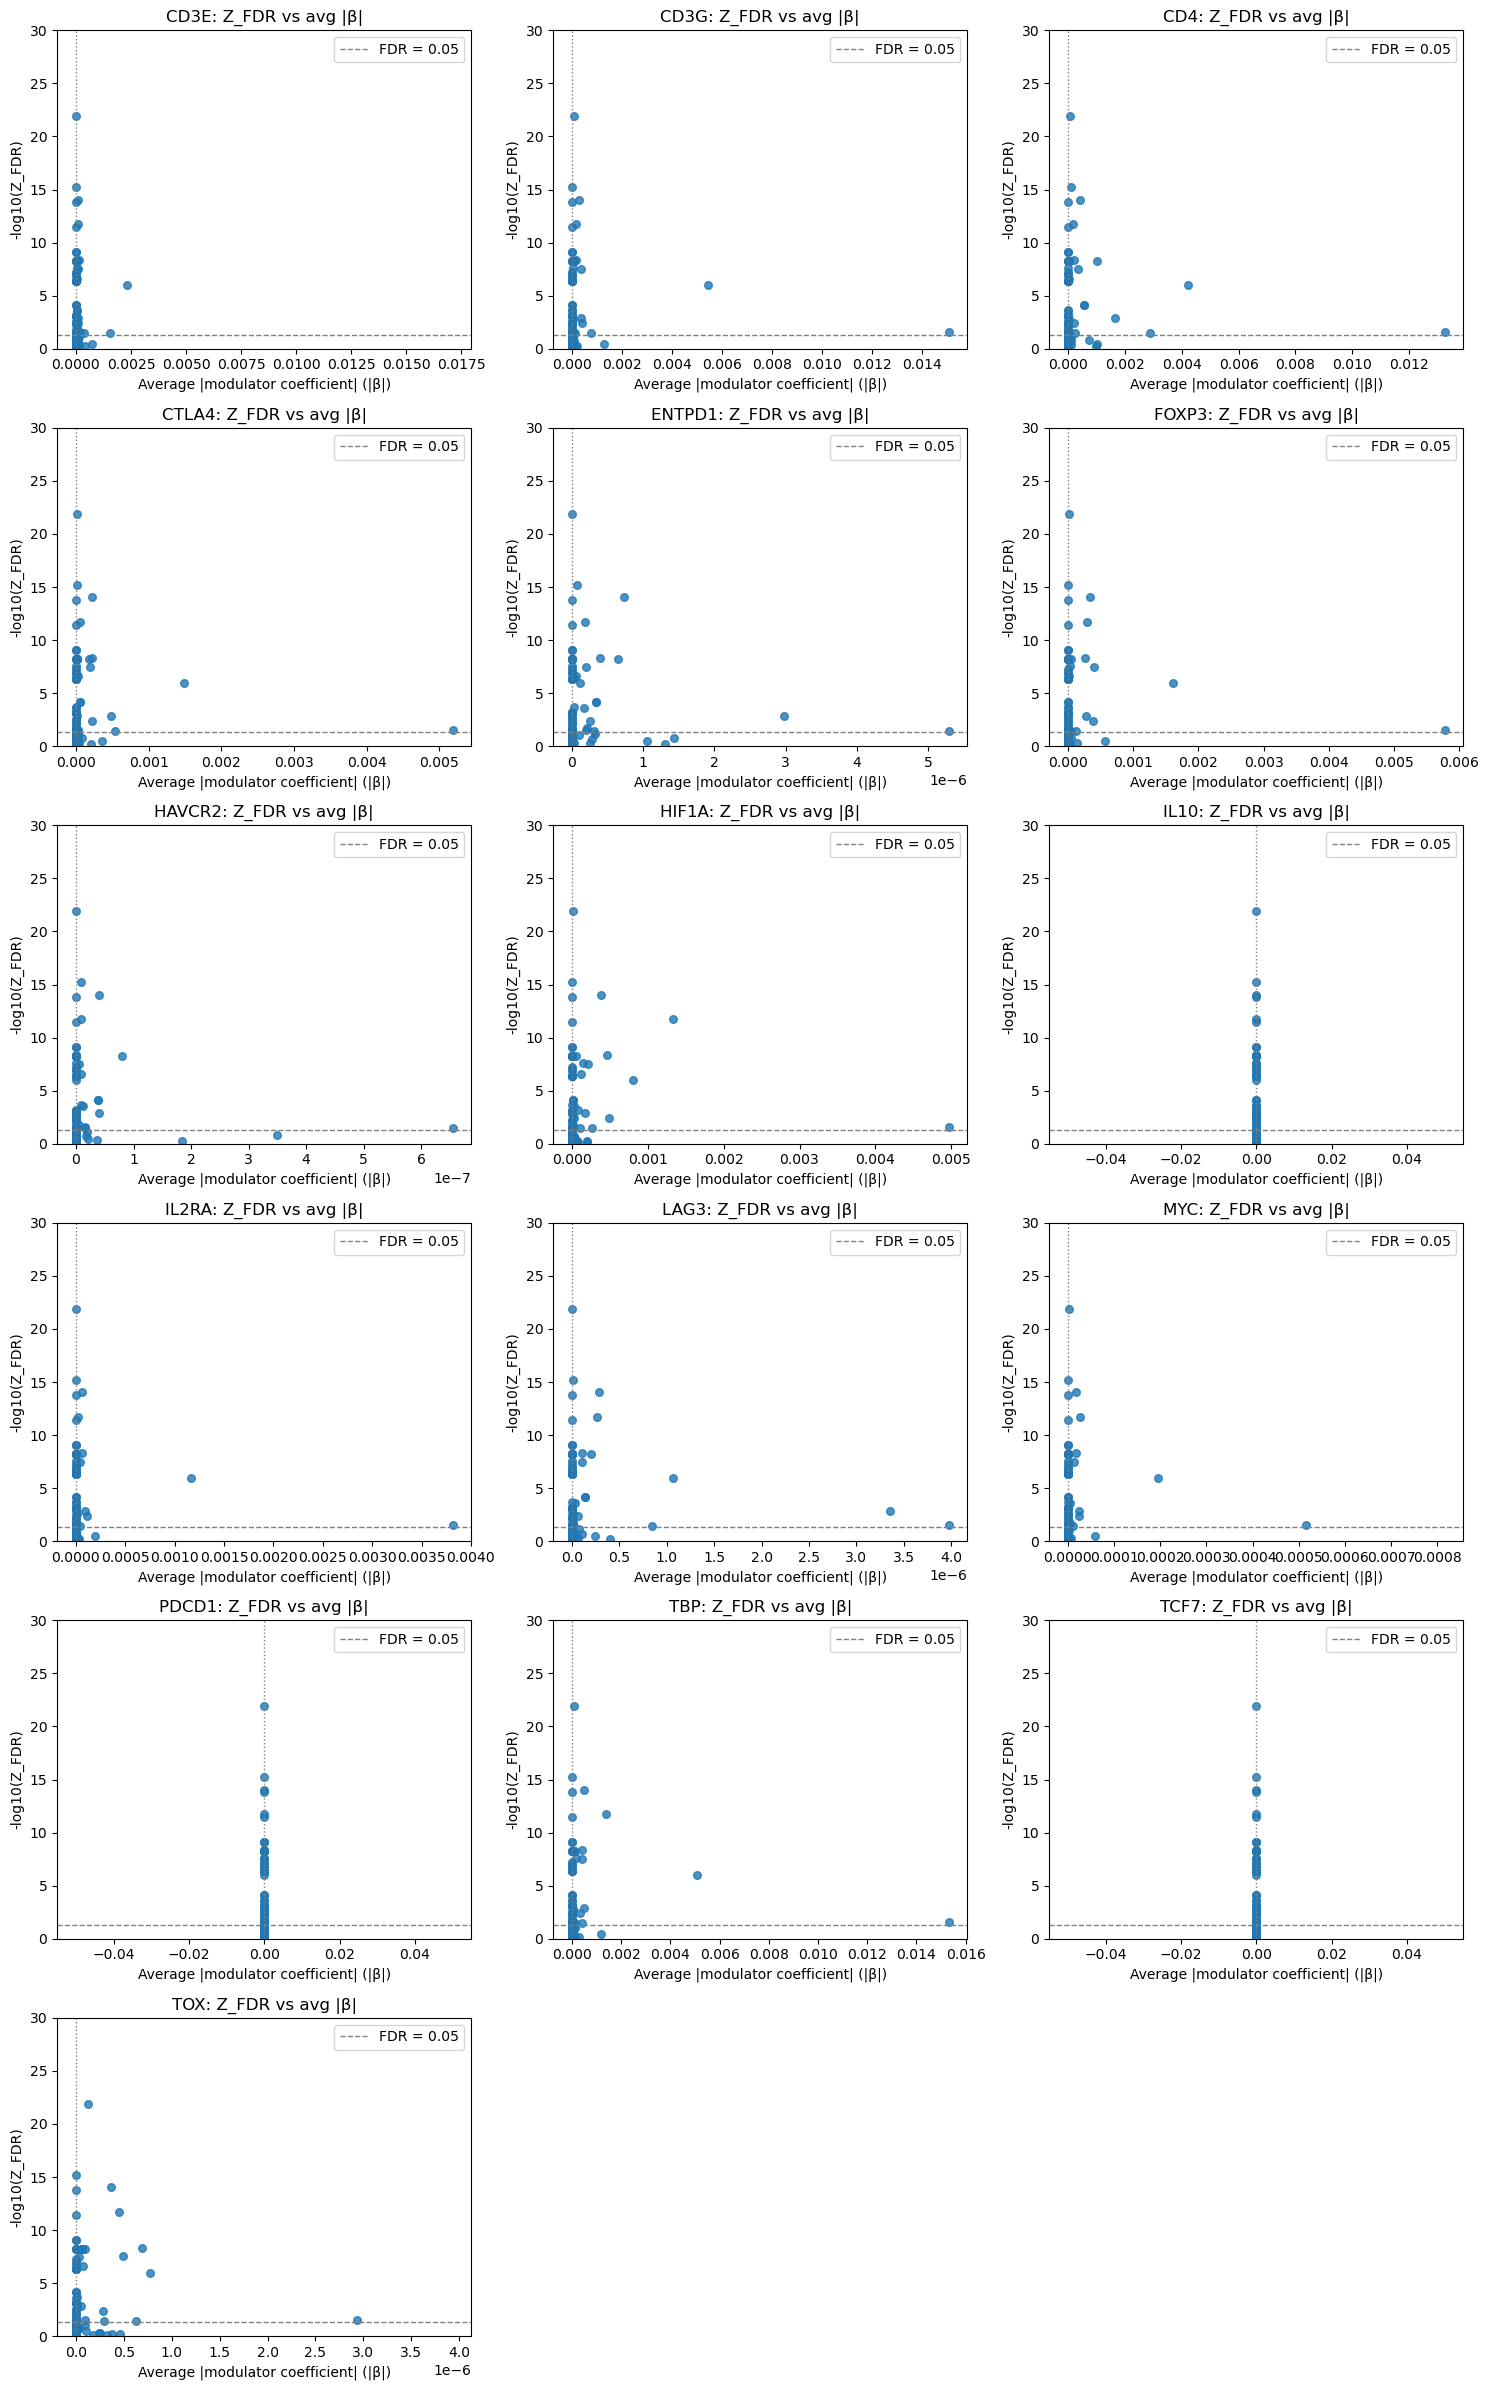

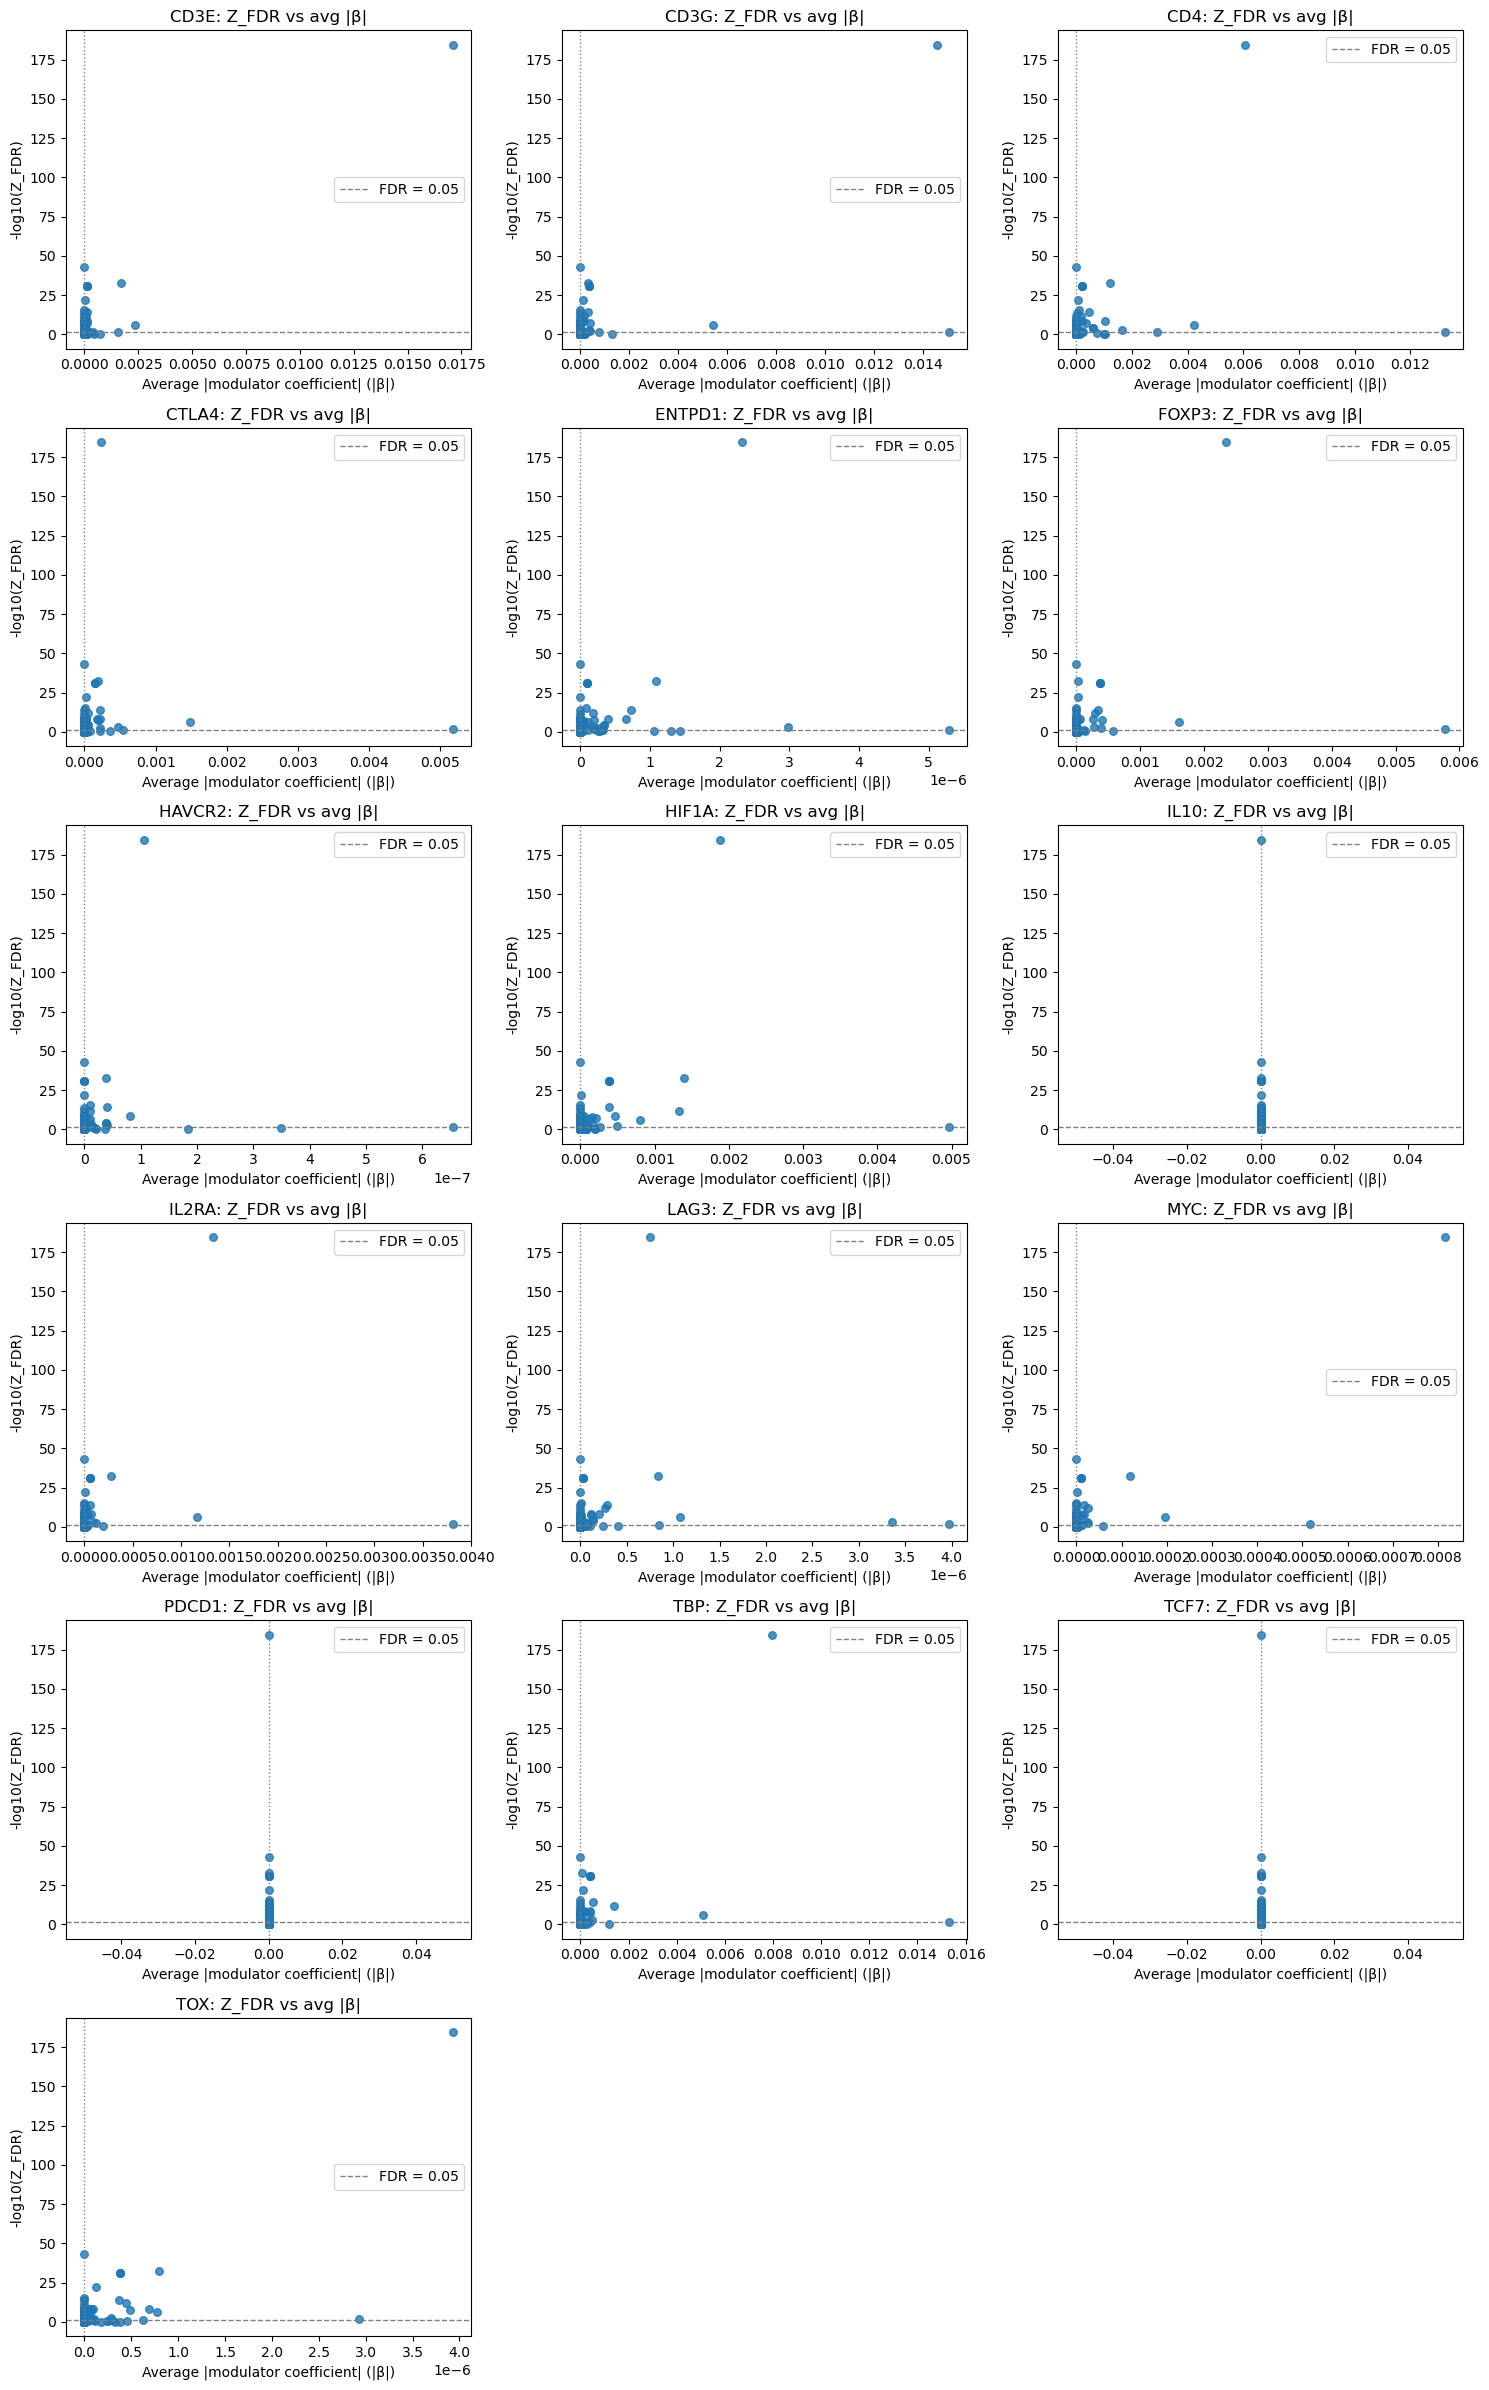

Dataset: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_4


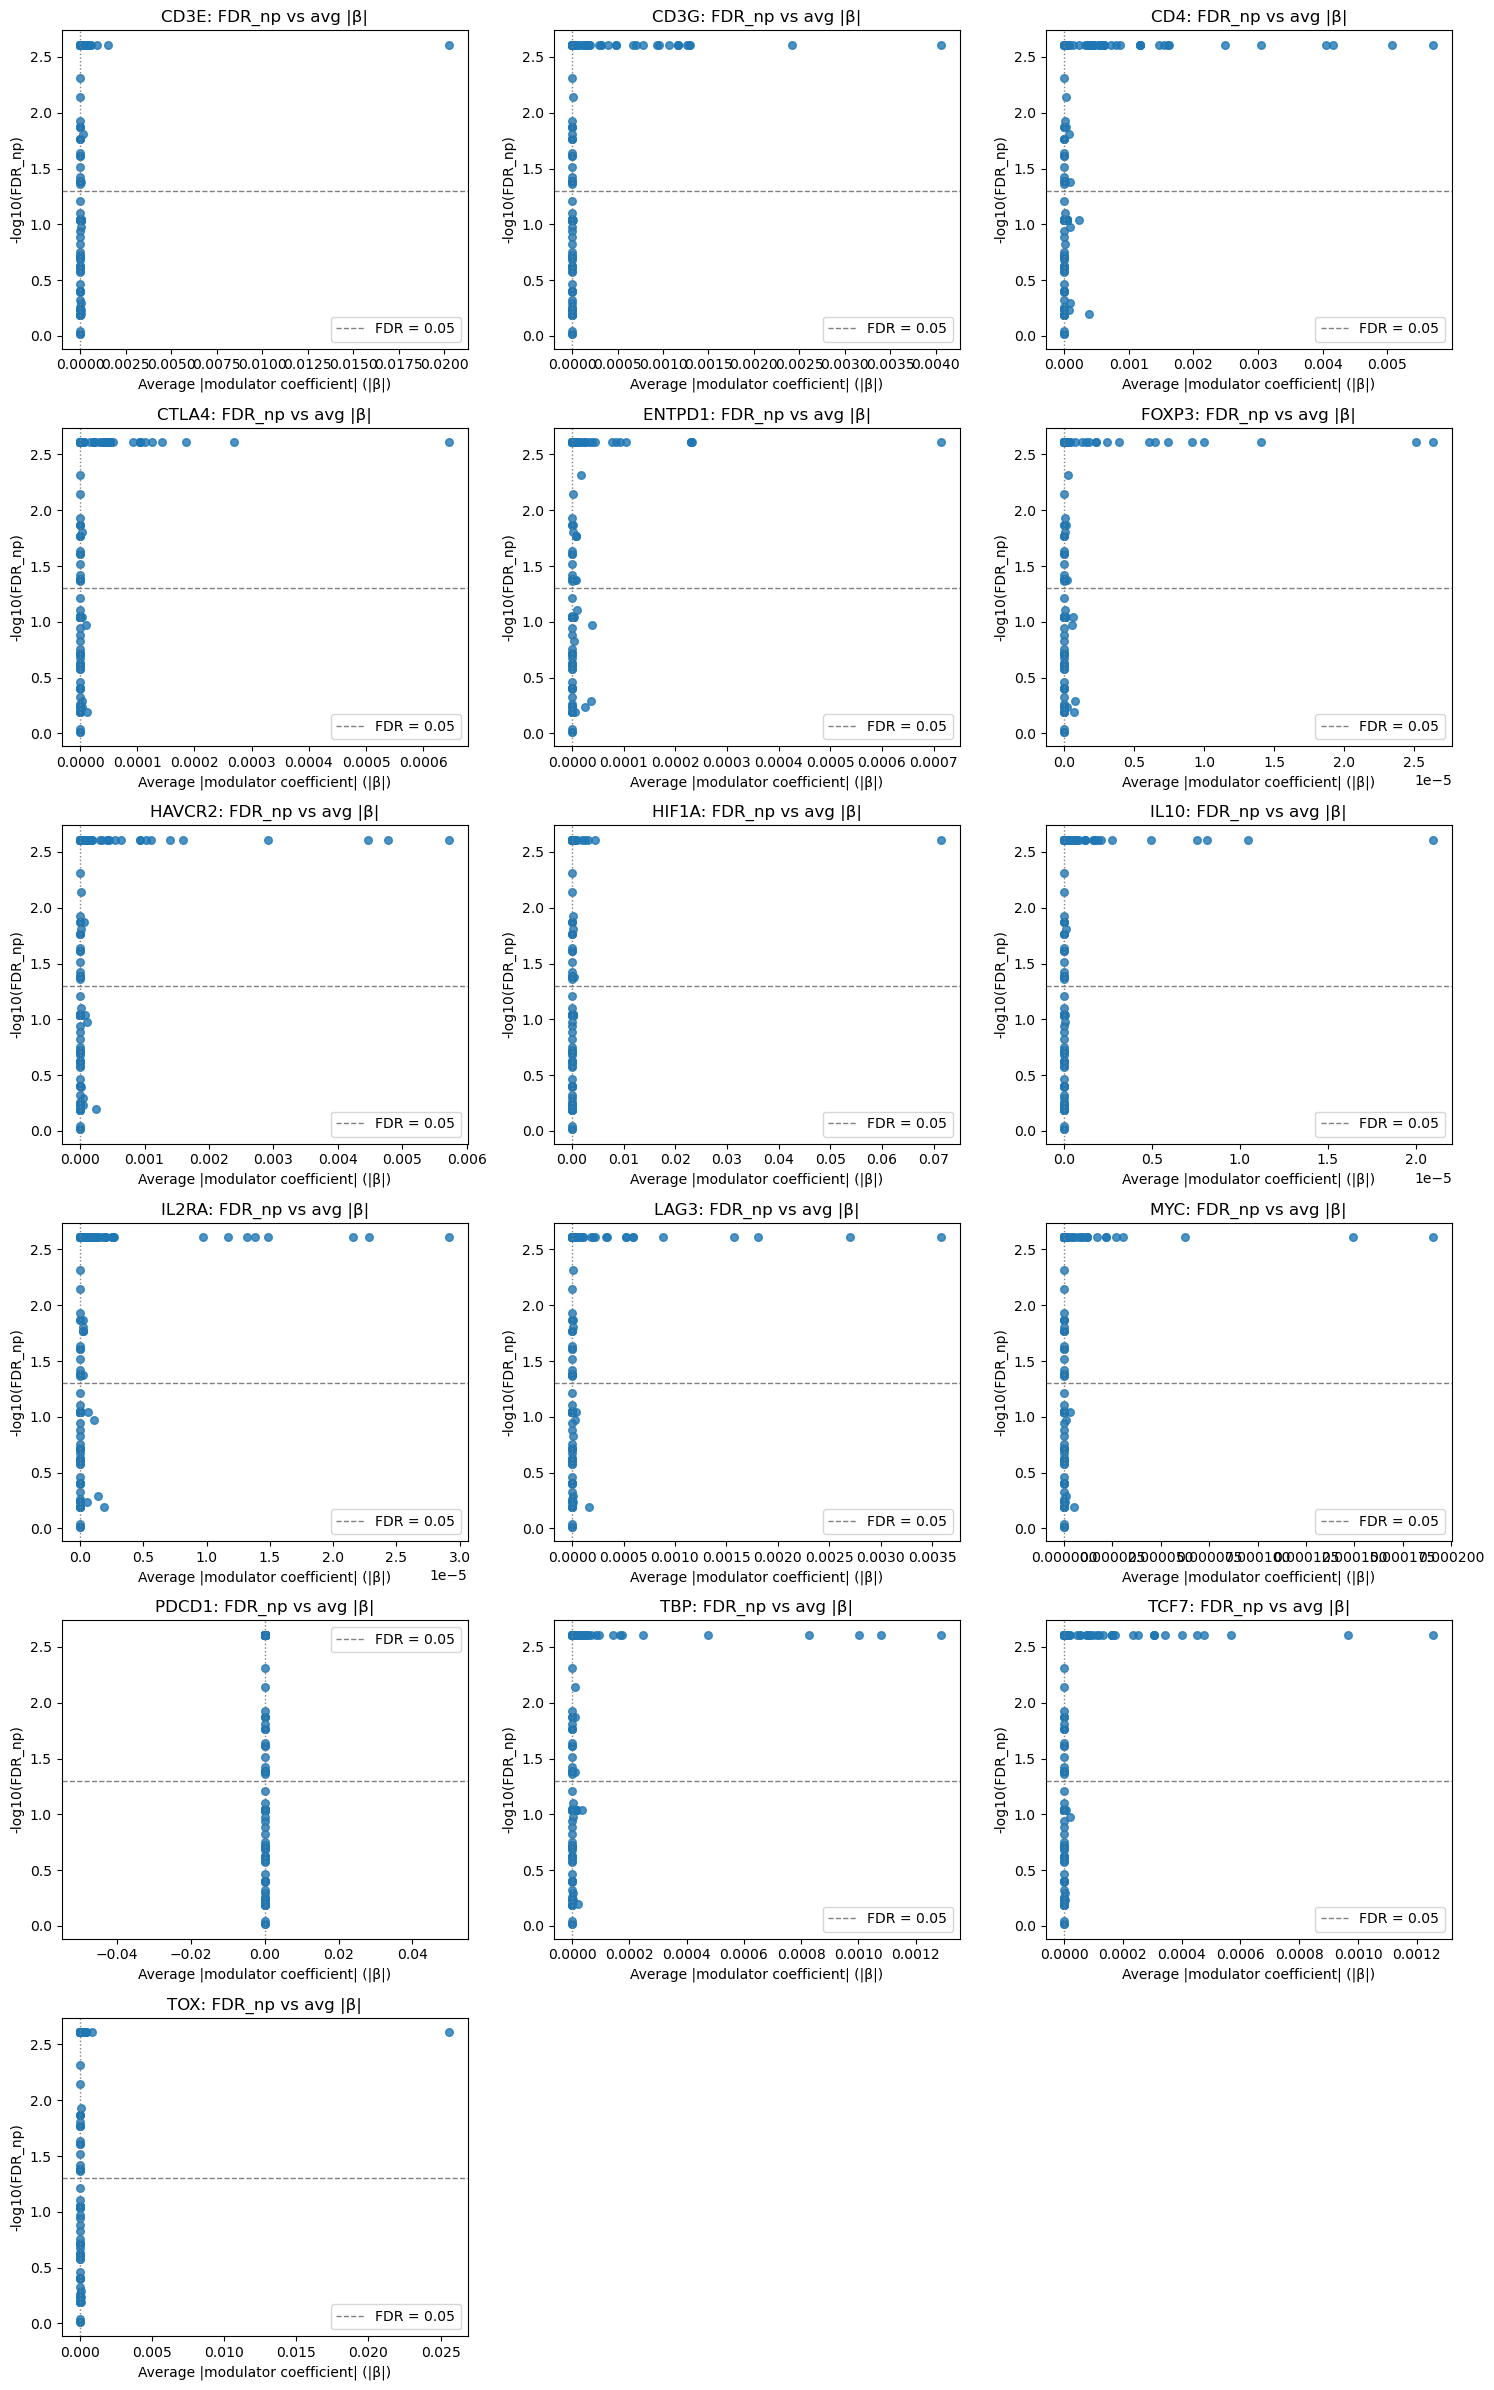

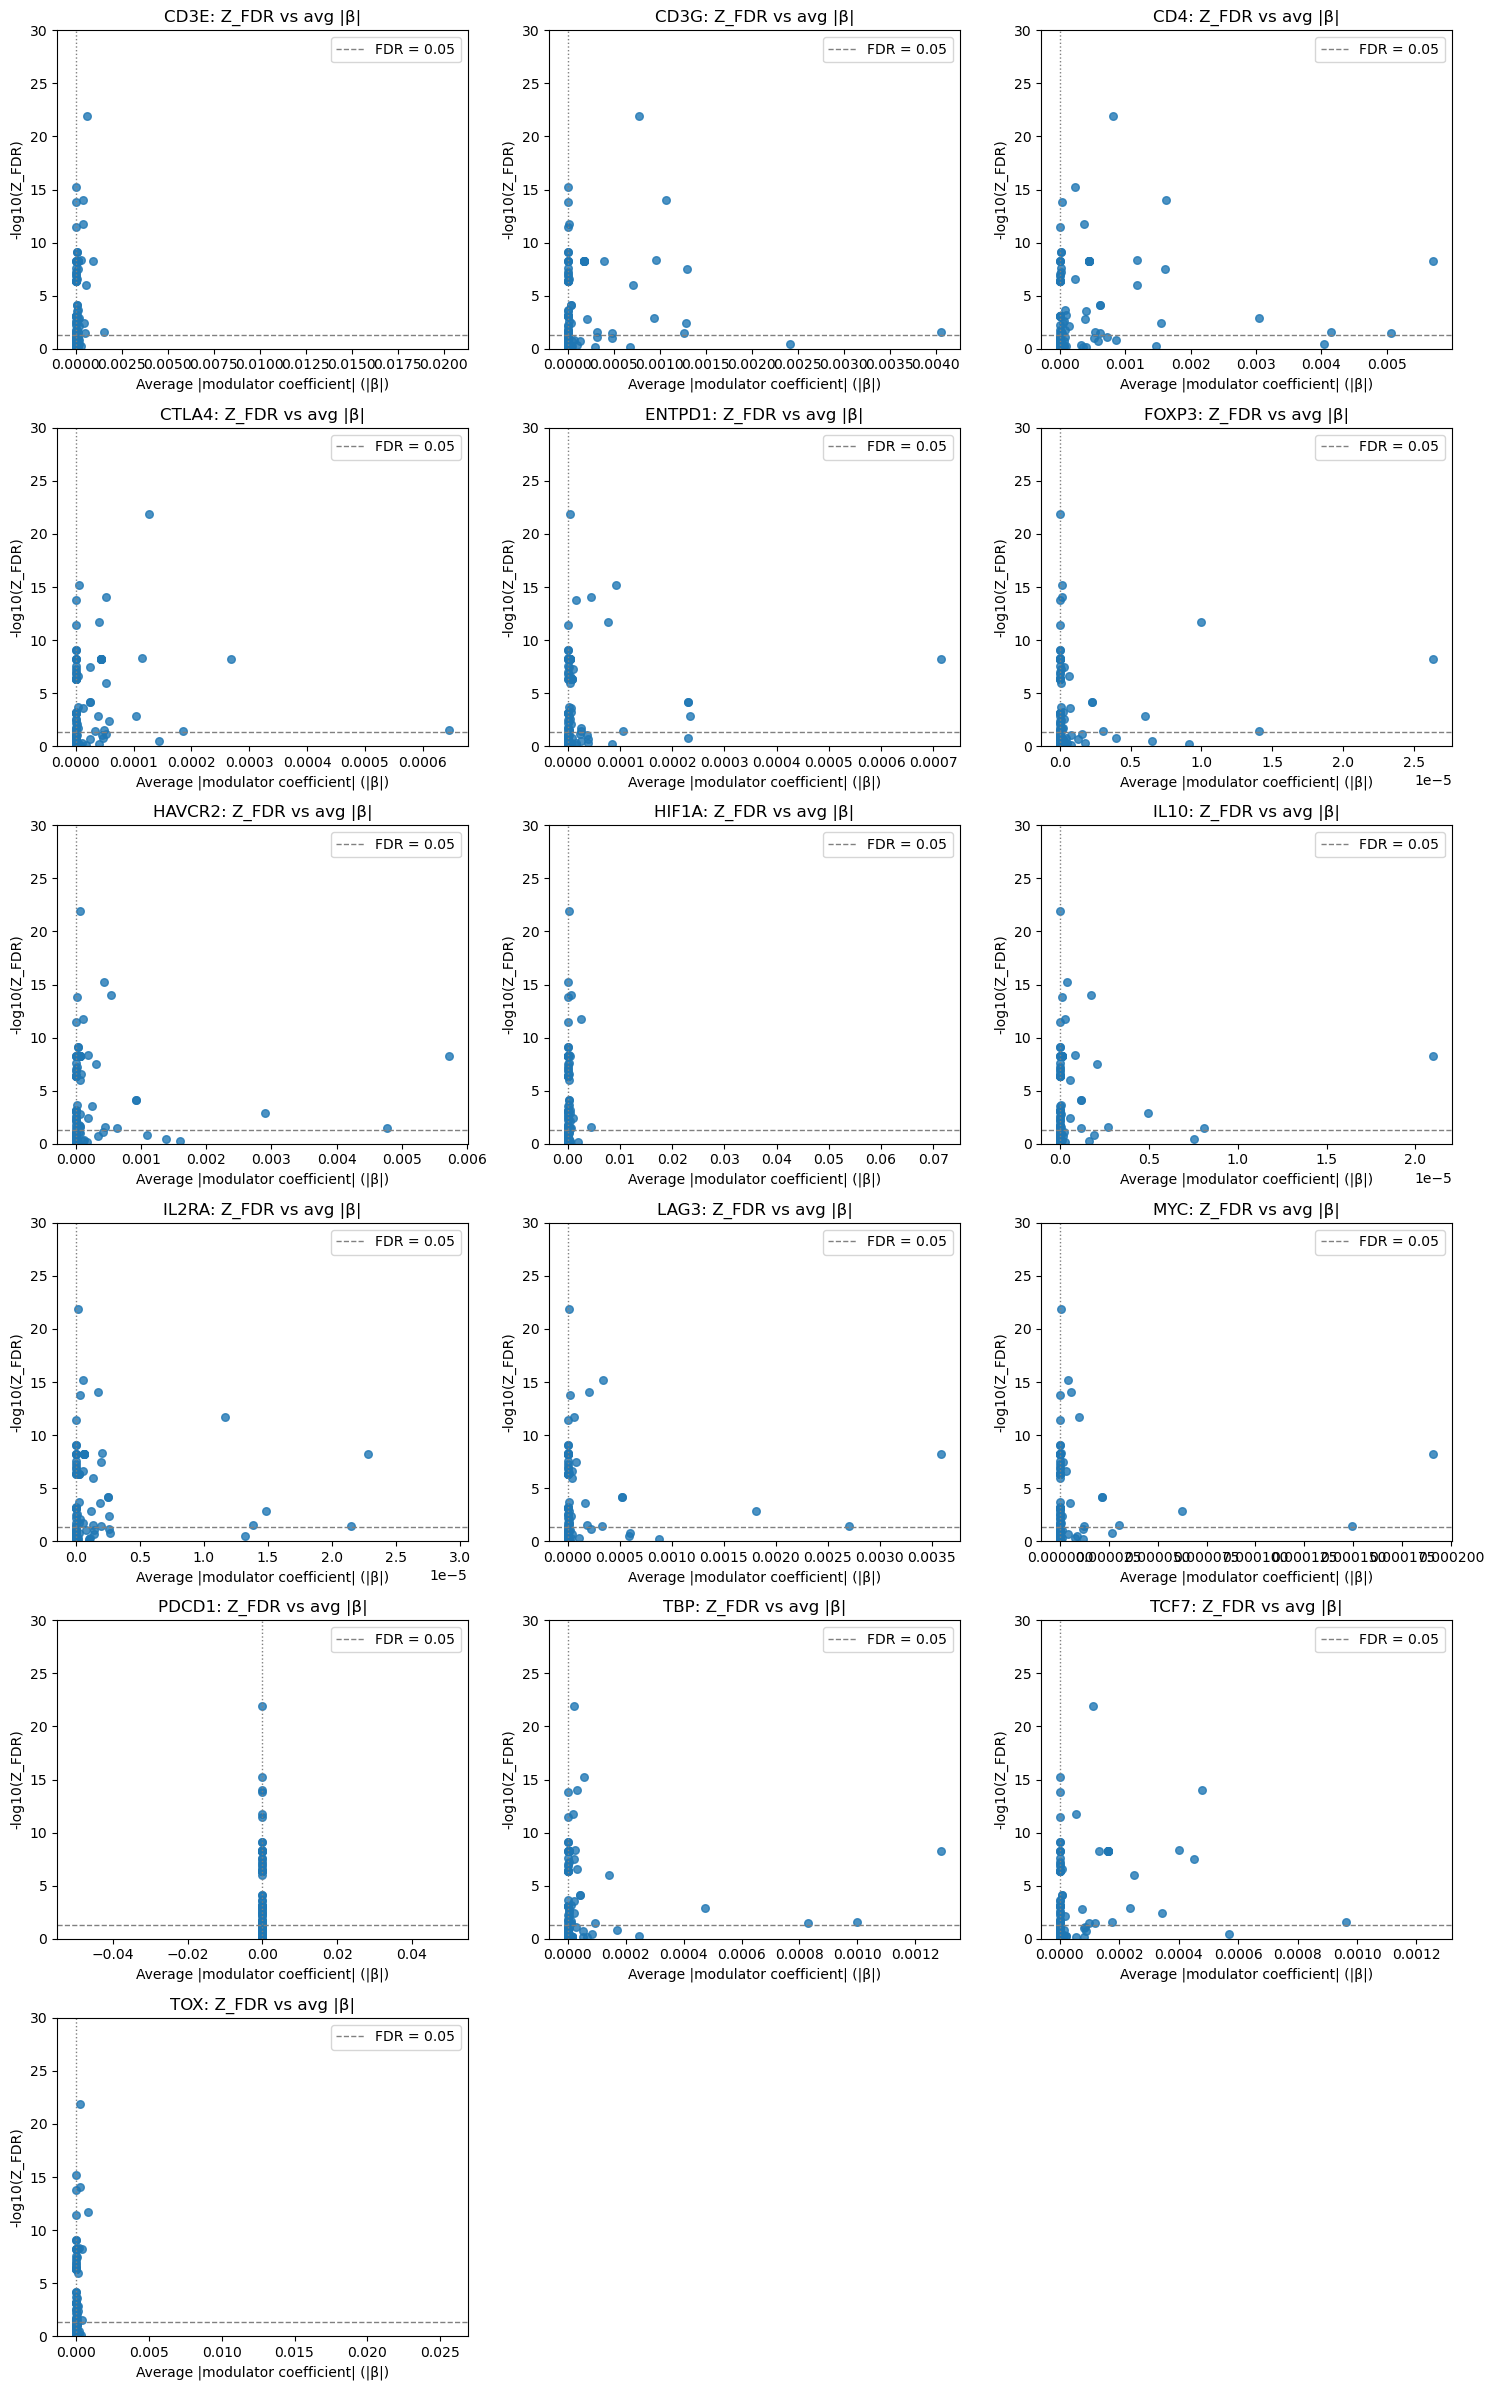

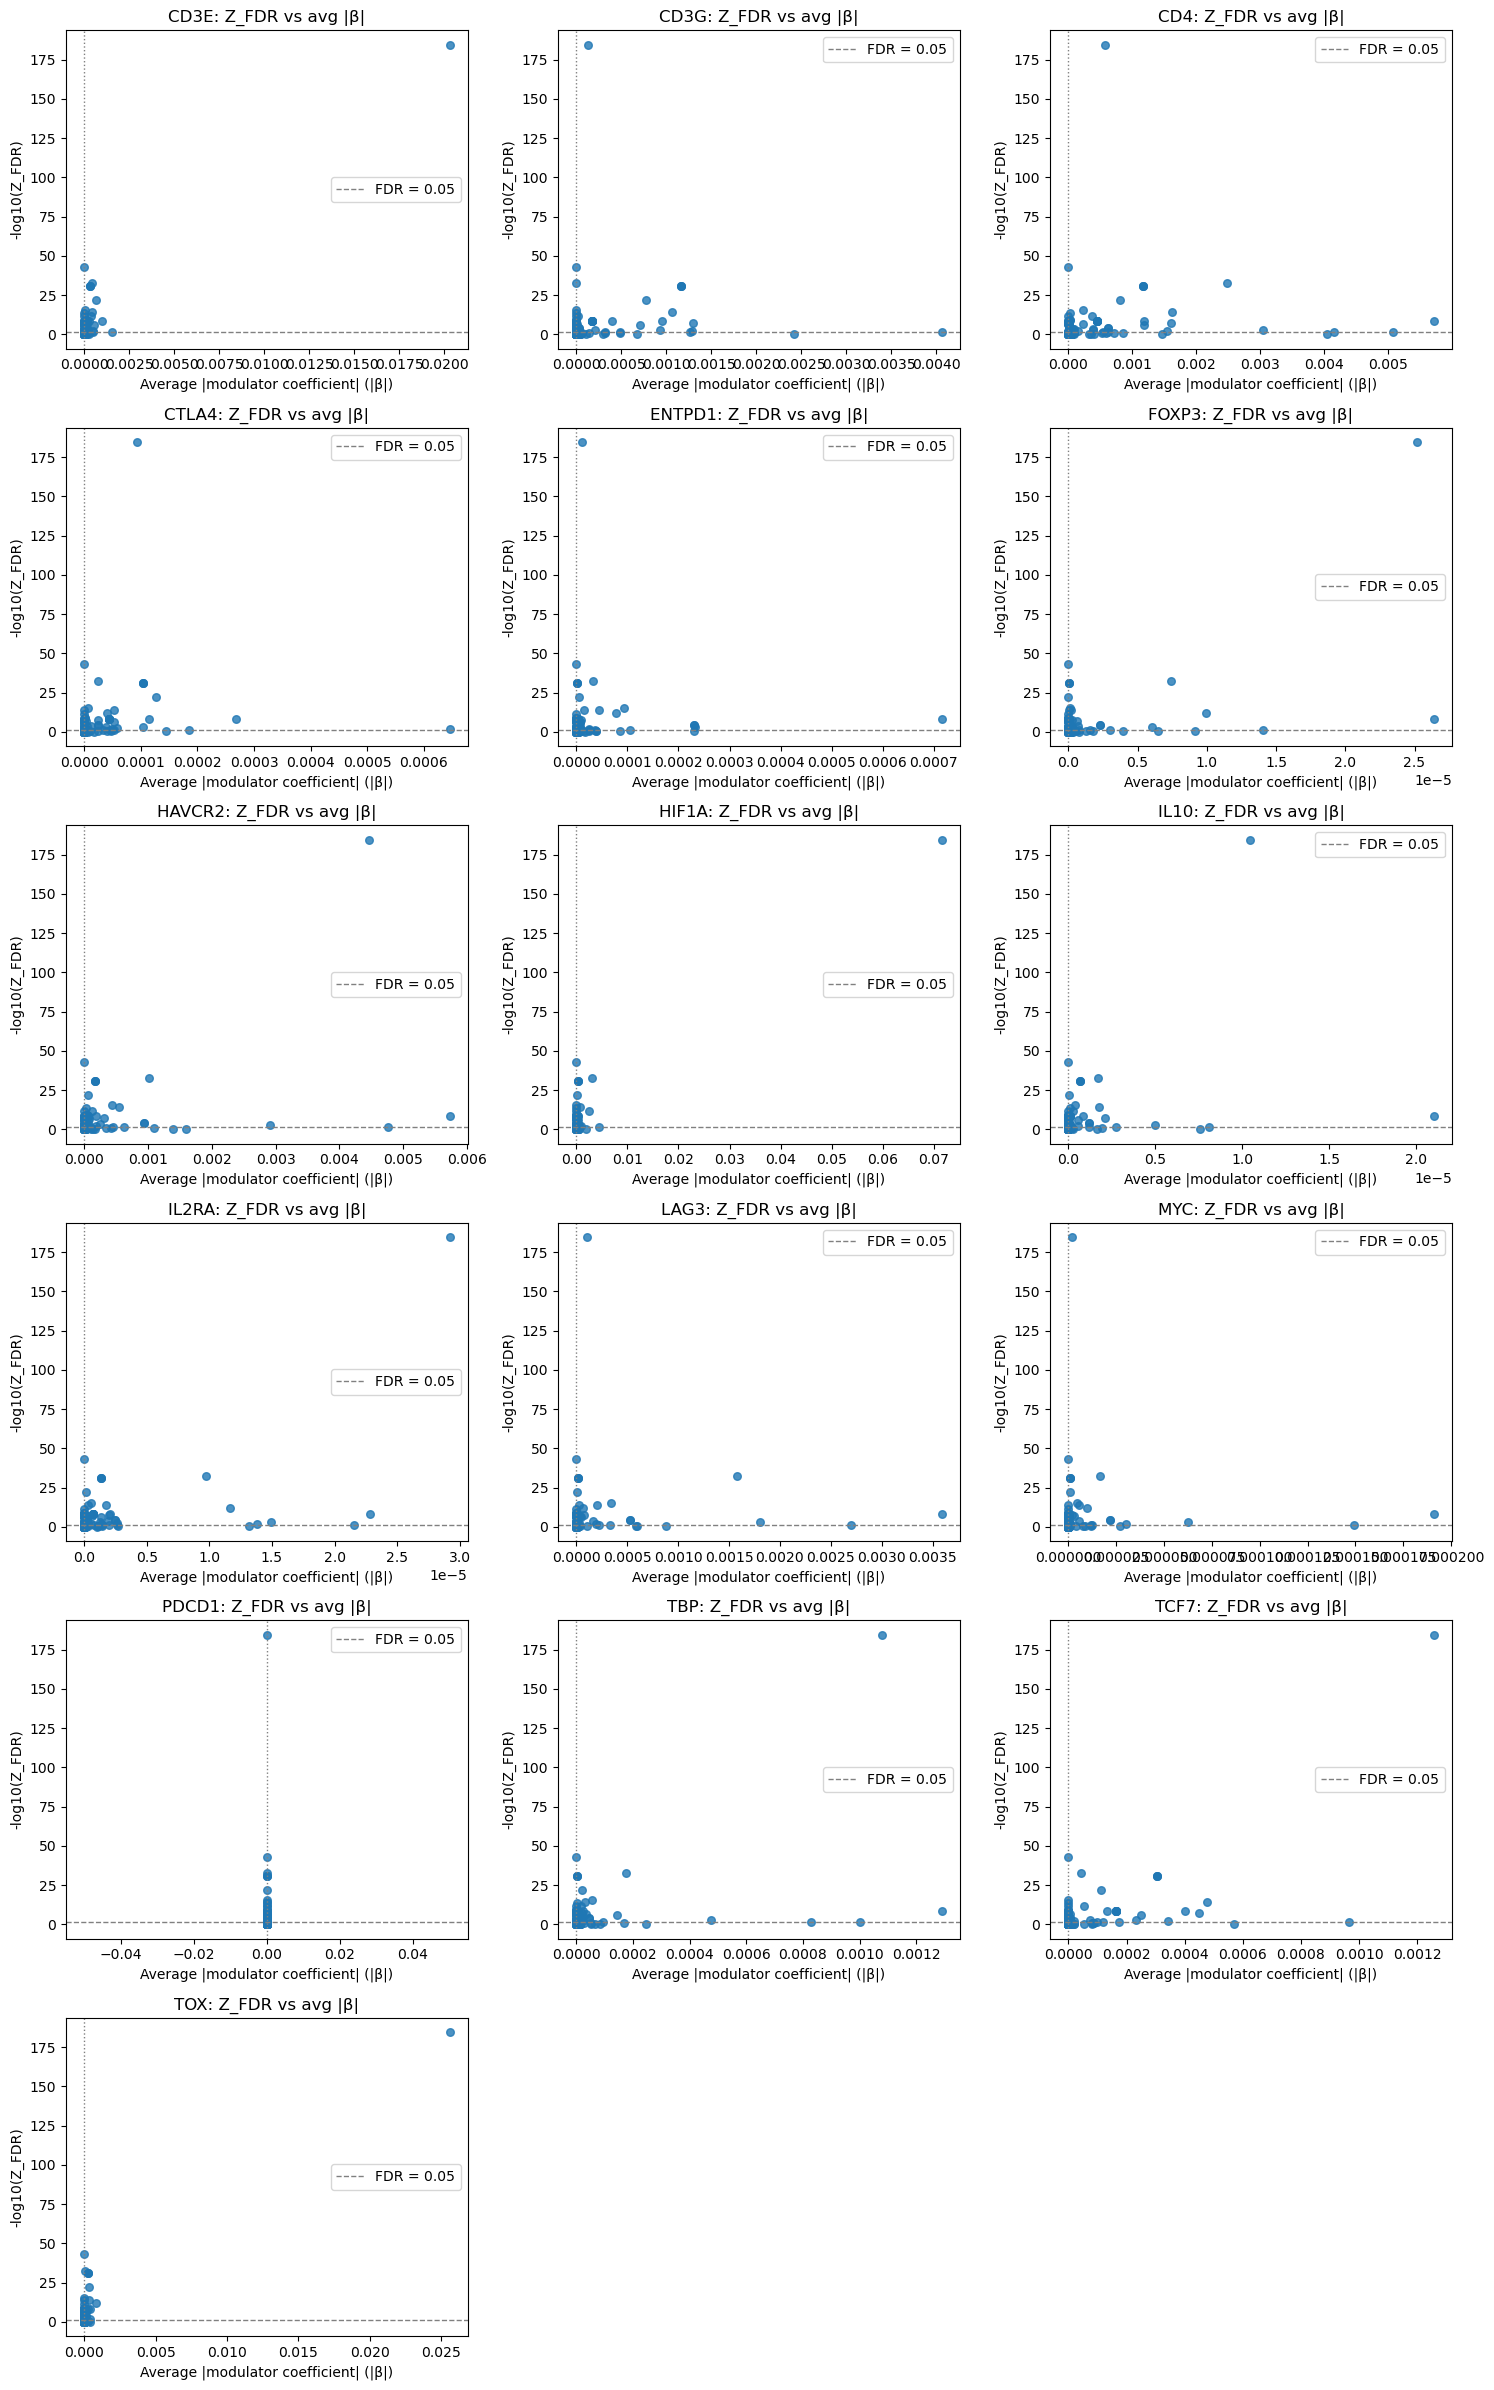

In [18]:
for slice_number in range(1, 5):
    dataset_name = f'{PATIENT}-Slice_{slice_number}'
    data_dir = f'{PROJECT_DIR}/{dataset_name}'
    slice_adata = sc.read_h5ad(f'{data_dir}/all_metab_spacetravlr_adata.h5ad')
    slice_genes = list(slice_adata.uns['beta_modulators'])
    dfs = extract_betas_all(slice_genes, slice_adata)
    print(f'Dataset: {data_dir}')
    plot_betas_grid(dfs, fdr_col='FDR_np', labels=False)
    plt.show()
    plot_betas_grid(dfs, fdr_col='Z_FDR', ylim=(0, 30), labels=False)
    plt.show()
    plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False)
    plt.show()